In [1]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import os

In [43]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import Lasso, ElasticNet, BayesianRidge, QuantileRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, StackingRegressor)
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [2]:
#Add for Visuals
PALETTE   = "viridis"
ACCENT    = "#2563EB"
HIGHLIGHT = "#DC2626"
NEUTRAL   = "#64748B"
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight",
                     "savefig.facecolor": "white"})

In [3]:
#Read the data
#The data source is from the BEA for 2022-2025
raw = pd.read_csv("GDPDollarByState.csv")
raw["Description"] = raw["Description"].str.strip()
print(f"Raw shape: {raw.shape}")

Raw shape: (1406, 20)


In [4]:
raw.head(5)

,GeoFIPS,GeoName,LineCode,Description,2022:Q1,2022:Q2,2022:Q3,2022:Q4,2023:Q1,2023:Q2,2023:Q3,2023:Q4,2024:Q1,2024:Q2,2024:Q3,2024:Q4,2025:Q1,2025:Q2,2025:Q3,2025:Q4
0,0,United States *,1,All industry total,25250347.0,25861292.0,26336304.0,26770514.0,27216445.0,27530055.0,28074846.0,28424722.0,28708161.0,29147044.0,29511664.0,29825182.0,30042113.0,30485729.0,31098027.0,31422526.0
1,0,United States *,2,Private industries,22370435.0,22958308.0,23394534.0,23792288.0,24186841.0,24462441.0,24949510.0,25252382.0,25477141.0,25871320.0,26193383.0,26464842.0,26639914.0,27051641.0,27629228.0,27939572.0
2,0,United States *,3,"Agriculture, forestry, fishing and hunting",271638.0,296635.0,300780.0,307138.0,302022.0,276696.0,261042.0,242003.0,256803.0,261204.0,268639.0,292099.0,293163.0,266907.0,265971.0,262013.0
3,0,United States *,6,"Mining, quarrying, and oil and gas extraction",420912.0,513633.0,496340.0,436892.0,403631.0,386371.0,424049.0,433225.0,406190.0,418263.0,403323.0,389216.0,411077.0,376031.0,379094.0,370940.0
4,0,United States *,10,Utilities,391678.0,452398.0,464923.0,454149.0,460092.0,463011.0,464068.0,443915.0,452495.0,459787.0,450744.0,454405.0,460146.0,460838.0,478277.0,485724.0


In [5]:
Q_COLS = [c for c in raw.columns if ":" in c]
print(f"Quarters: {Q_COLS}")

Quarters: ['2022:Q1', '2022:Q2', '2022:Q3', '2022:Q4', '2023:Q1', '2023:Q2', '2023:Q3', '2023:Q4', '2024:Q1', '2024:Q2', '2024:Q3', '2024:Q4', '2025:Q1', '2025:Q2', '2025:Q3', '2025:Q4']


In [6]:
# Convert quarter values to numeric (they may contain commas or spaces)
for q in Q_COLS:
    raw[q] = pd.to_numeric(raw[q].astype(str).str.replace(",", ""), errors="coerce")

In [7]:
# Build long-format DataFrame
long = raw.melt(id_vars=["GeoFIPS", "GeoName", "LineCode", "Description"],
                value_vars=Q_COLS, var_name="Quarter", value_name="GDP_M")

In [8]:
# Create a function for reason: Parse quarter -> period index
def qstr_to_period(s):
    yr, q = s.split(":")
    month = {"Q1": 1, "Q2": 4, "Q3": 7, "Q4": 10}[q]
    return pd.Period(f"{yr}Q{q[1]}")

In [9]:
long["Period"] = long["Quarter"].apply(qstr_to_period)
long["Year"] = long["Period"].apply(lambda p: p.year)
long["Qtr"] = long["Period"].apply(lambda p: p.quarter)
long["GDP_B"] = long["GDP_M"] / 1_000          # millions -> billions
long["GDP_T"] = long["GDP_M"] / 1_000_000      # millions -> trillions
long = long.sort_values(["GeoName", "Description", "Period"])

In [10]:
#Subset: only US-level "All industry total" → national GDP time series
us_total = long[(long["GeoName"] == "United States *") &
                (long["Description"] == "All industry total")].copy()
 
# State-level "All industry total" (excluding US total and overseas)
state_total = long[(long["GeoName"] != "United States *") &
                   (~long["GeoName"].str.contains("overseas", case=False)) &
                   (long["Description"] == "All industry total")].copy()
 
# Industry breakdown at US level
us_industry = long[(long["GeoName"] == "United States *") &
                   (~long["Description"].str.contains("overseas", case=False))].copy()

In [11]:
# Compute QoQ growth for states
state_total["QoQ_Growth"] = (
    state_total.sort_values("Period")
               .groupby("GeoName")["GDP_M"]
               .pct_change() * 100
)

In [12]:
print(f"\nUS total quarters: {len(us_total)}")
print(f"State rows: {len(state_total)}")
print(f"Industry rows (US): {len(us_industry)}")
print(f"\nGDP Range (US All-industry): "
      f"${us_total['GDP_T'].min():.2f}T – ${us_total['GDP_T'].max():.2f}T")
 


US total quarters: 16
State rows: 816
Industry rows (US): 432

GDP Range (US All-industry): $25.25T – $31.42T


In [13]:
state_pivot = state_total.pivot_table(
    index="GeoName", columns="Quarter", values="GDP_M")
 
print(f"\nState pivot shape: {state_pivot.shape}")


State pivot shape: (51, 16)


In [14]:
%matplotlib inline

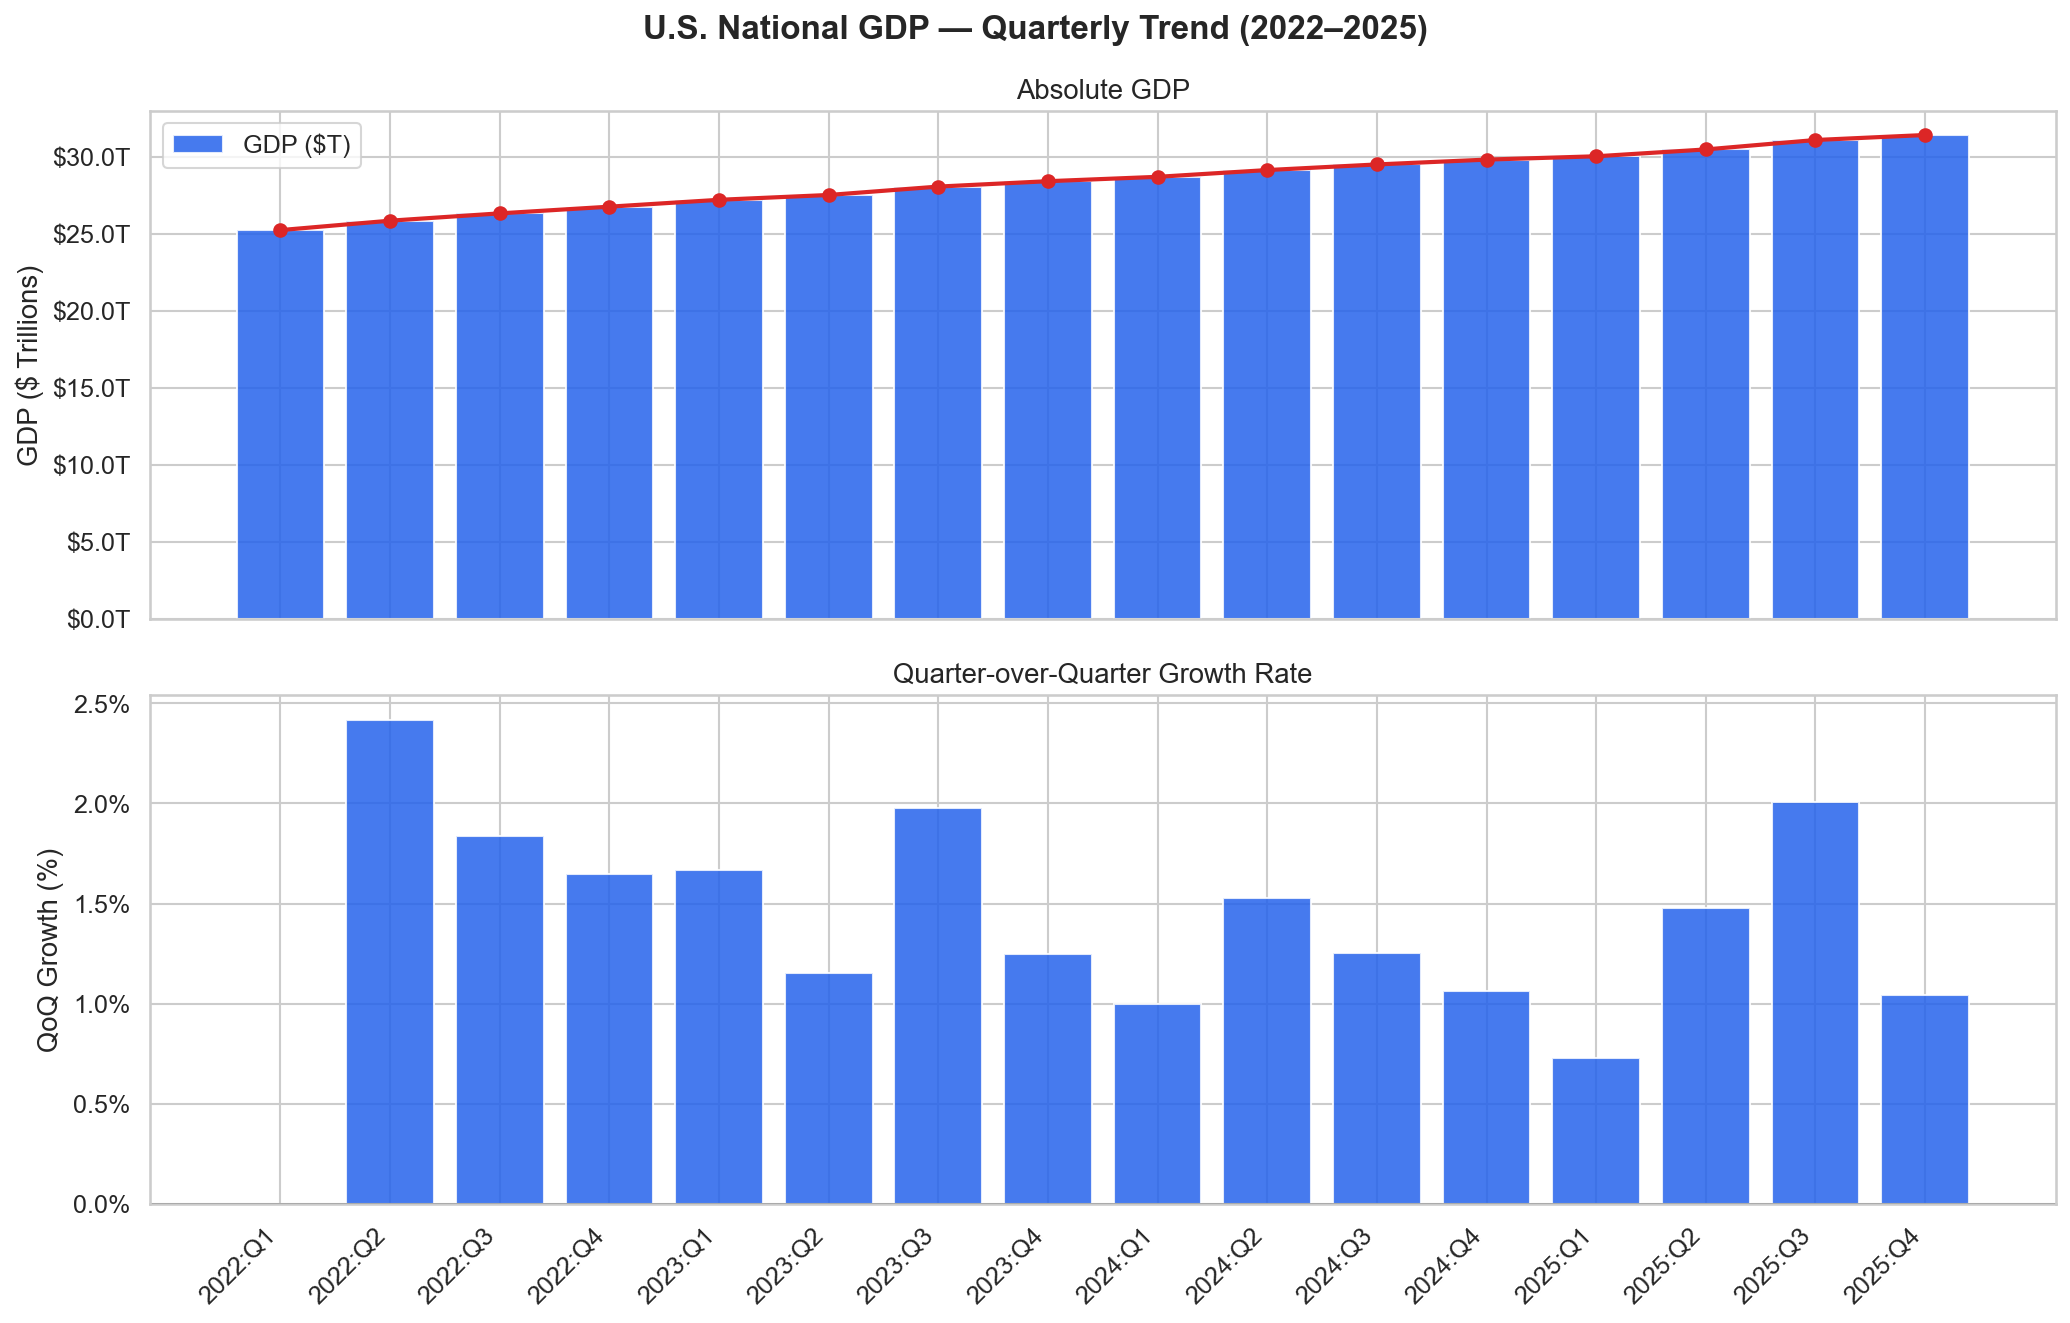

In [15]:
# ── 1-A  US National GDP Time Series ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle("U.S. National GDP — Quarterly Trend (2022–2025)", fontsize=16, fontweight="bold")
 
xs = list(range(len(us_total)))
xs_labels = us_total["Quarter"].tolist()
 
axes[0].bar(xs, us_total["GDP_T"], color=ACCENT, alpha=0.85, label="GDP ($T)")
axes[0].plot(xs, us_total["GDP_T"], color=HIGHLIGHT, marker="o", linewidth=2)
axes[0].set_ylabel("GDP ($ Trillions)")
axes[0].set_title("Absolute GDP")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:.1f}T"))
axes[0].legend()
 
qoq = us_total["GDP_T"].pct_change() * 100
colors = [ACCENT if v >= 0 else HIGHLIGHT for v in qoq.fillna(0)]
axes[1].bar(xs, qoq, color=colors, alpha=0.85)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("QoQ Growth (%)")
axes[1].set_title("Quarter-over-Quarter Growth Rate")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.1f}%"))
axes[1].set_xticks(xs)
axes[1].set_xticklabels(xs_labels, rotation=45, ha="right")
 
plt.tight_layout()
plt.show()

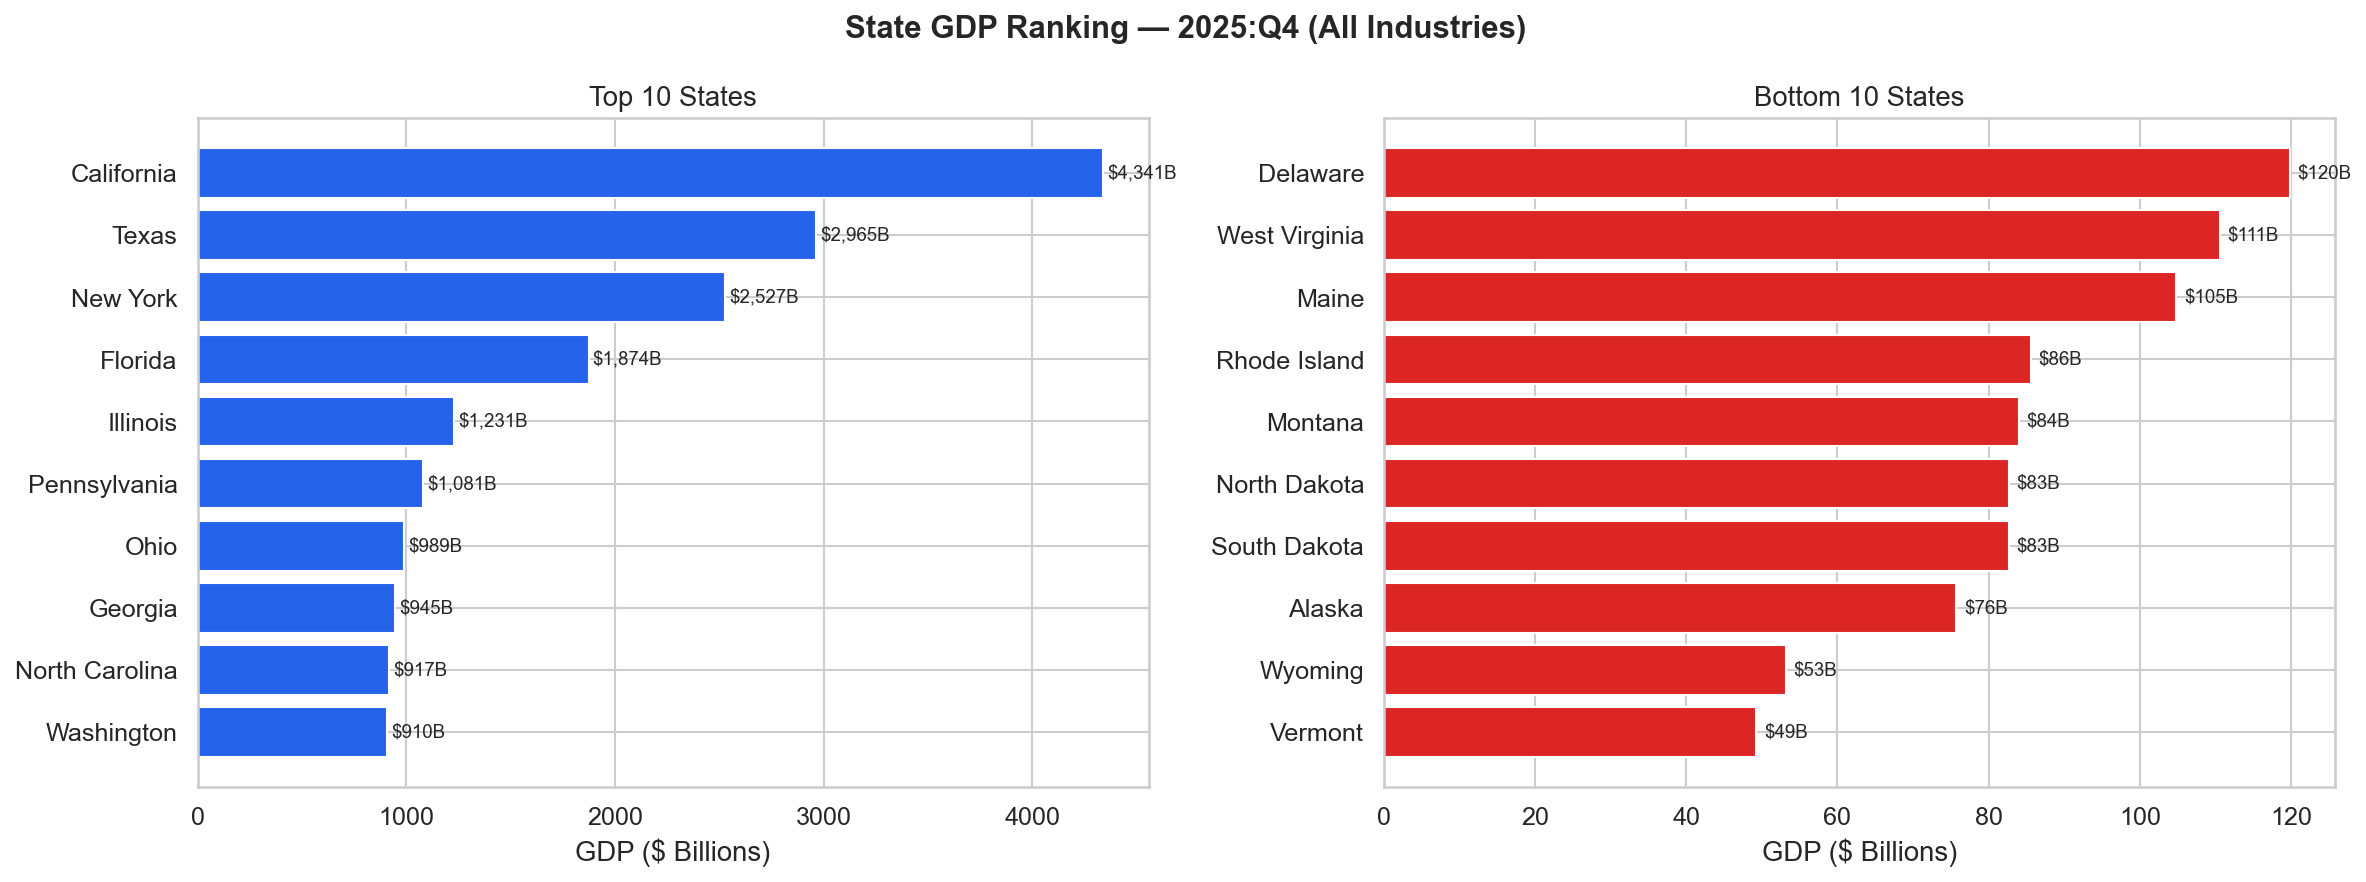

In [16]:
# ── 1-B  Top-10 States by Latest Quarter GDP ──────────────────────────────
latest_q = Q_COLS[-1]
state_latest = state_total[state_total["Quarter"] == latest_q].sort_values("GDP_B", ascending=False)
top10 = state_latest.head(10)
bot10 = state_latest.tail(10)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"State GDP Ranking — {latest_q} (All Industries)", fontsize=15, fontweight="bold")
 
bars = axes[0].barh(top10["GeoName"][::-1], top10["GDP_B"][::-1], color=ACCENT)
axes[0].set_xlabel("GDP ($ Billions)")
axes[0].set_title("Top 10 States")
for bar, val in zip(bars, top10["GDP_B"][::-1]):
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f"${val:,.0f}B", va="center", fontsize=9)
bars2 = axes[1].barh(bot10["GeoName"][::-1], bot10["GDP_B"][::-1], color=HIGHLIGHT)
axes[1].set_xlabel("GDP ($ Billions)")
axes[1].set_title("Bottom 10 States")
for bar, val in zip(bars2, bot10["GDP_B"][::-1]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f"${val:,.0f}B", va="center", fontsize=9)
plt.tight_layout()
plt.show()

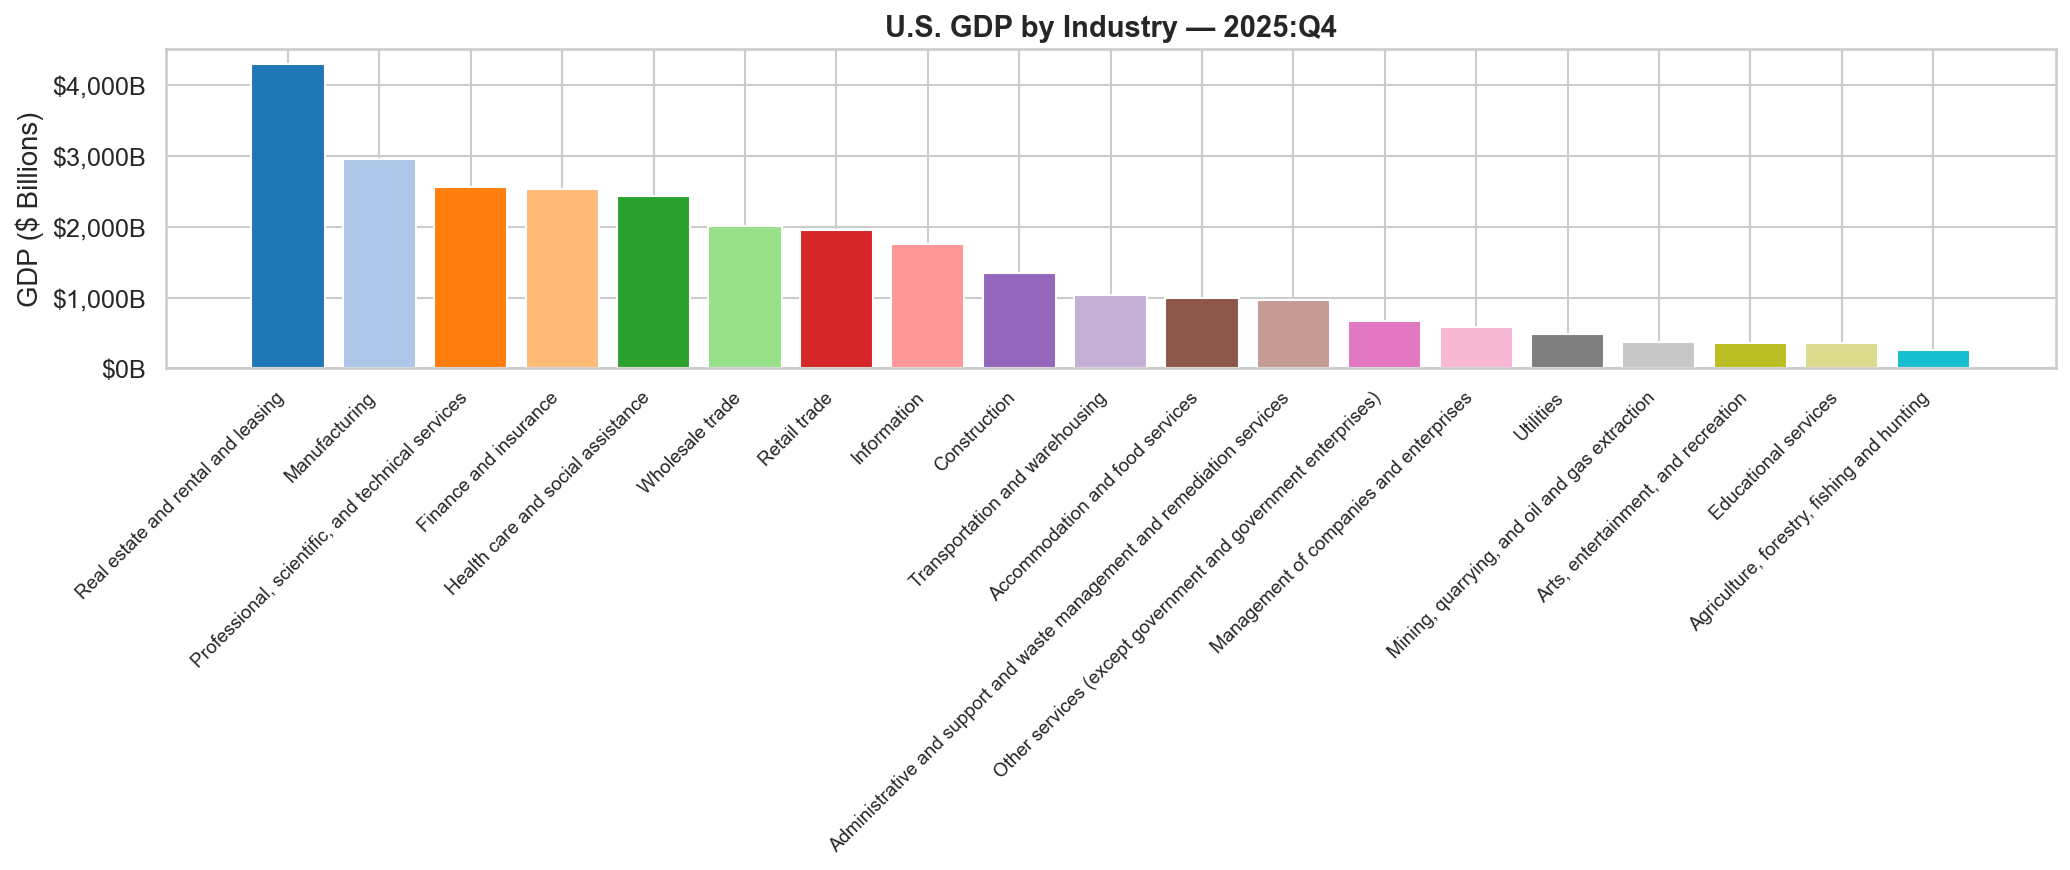

In [17]:
# ── 1-C  Industry Composition (US, Latest Quarter) ────────────────────────
industry_excl = [
    "All industry total", "Private industries",
    "Government and government enterprises",
    "All industry total, overseas activity",
    "Government and government enterprises, overseas activity",
    "Durable goods manufacturing", "Nondurable goods manufacturing",
    "Federal civilian", "Military", "State and local"
]
us_ind_latest = us_industry[
    (us_industry["Quarter"] == latest_q) &
    (~us_industry["Description"].isin(industry_excl))
].copy()
us_ind_latest = us_ind_latest.sort_values("GDP_B", ascending=False)
 
fig, ax = plt.subplots(figsize=(14, 6))
colors_pie = plt.cm.tab20.colors[:len(us_ind_latest)]
bars = ax.bar(range(len(us_ind_latest)), us_ind_latest["GDP_B"], color=colors_pie)
ax.set_xticks(range(len(us_ind_latest)))
ax.set_xticklabels([d.replace("      ", "").replace("  ", "") 
                    for d in us_ind_latest["Description"]],
                   rotation=45, ha="right", fontsize=9)
ax.set_ylabel("GDP ($ Billions)")
ax.set_title(f"U.S. GDP by Industry — {latest_q}", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}B"))
plt.tight_layout()
plt.show()

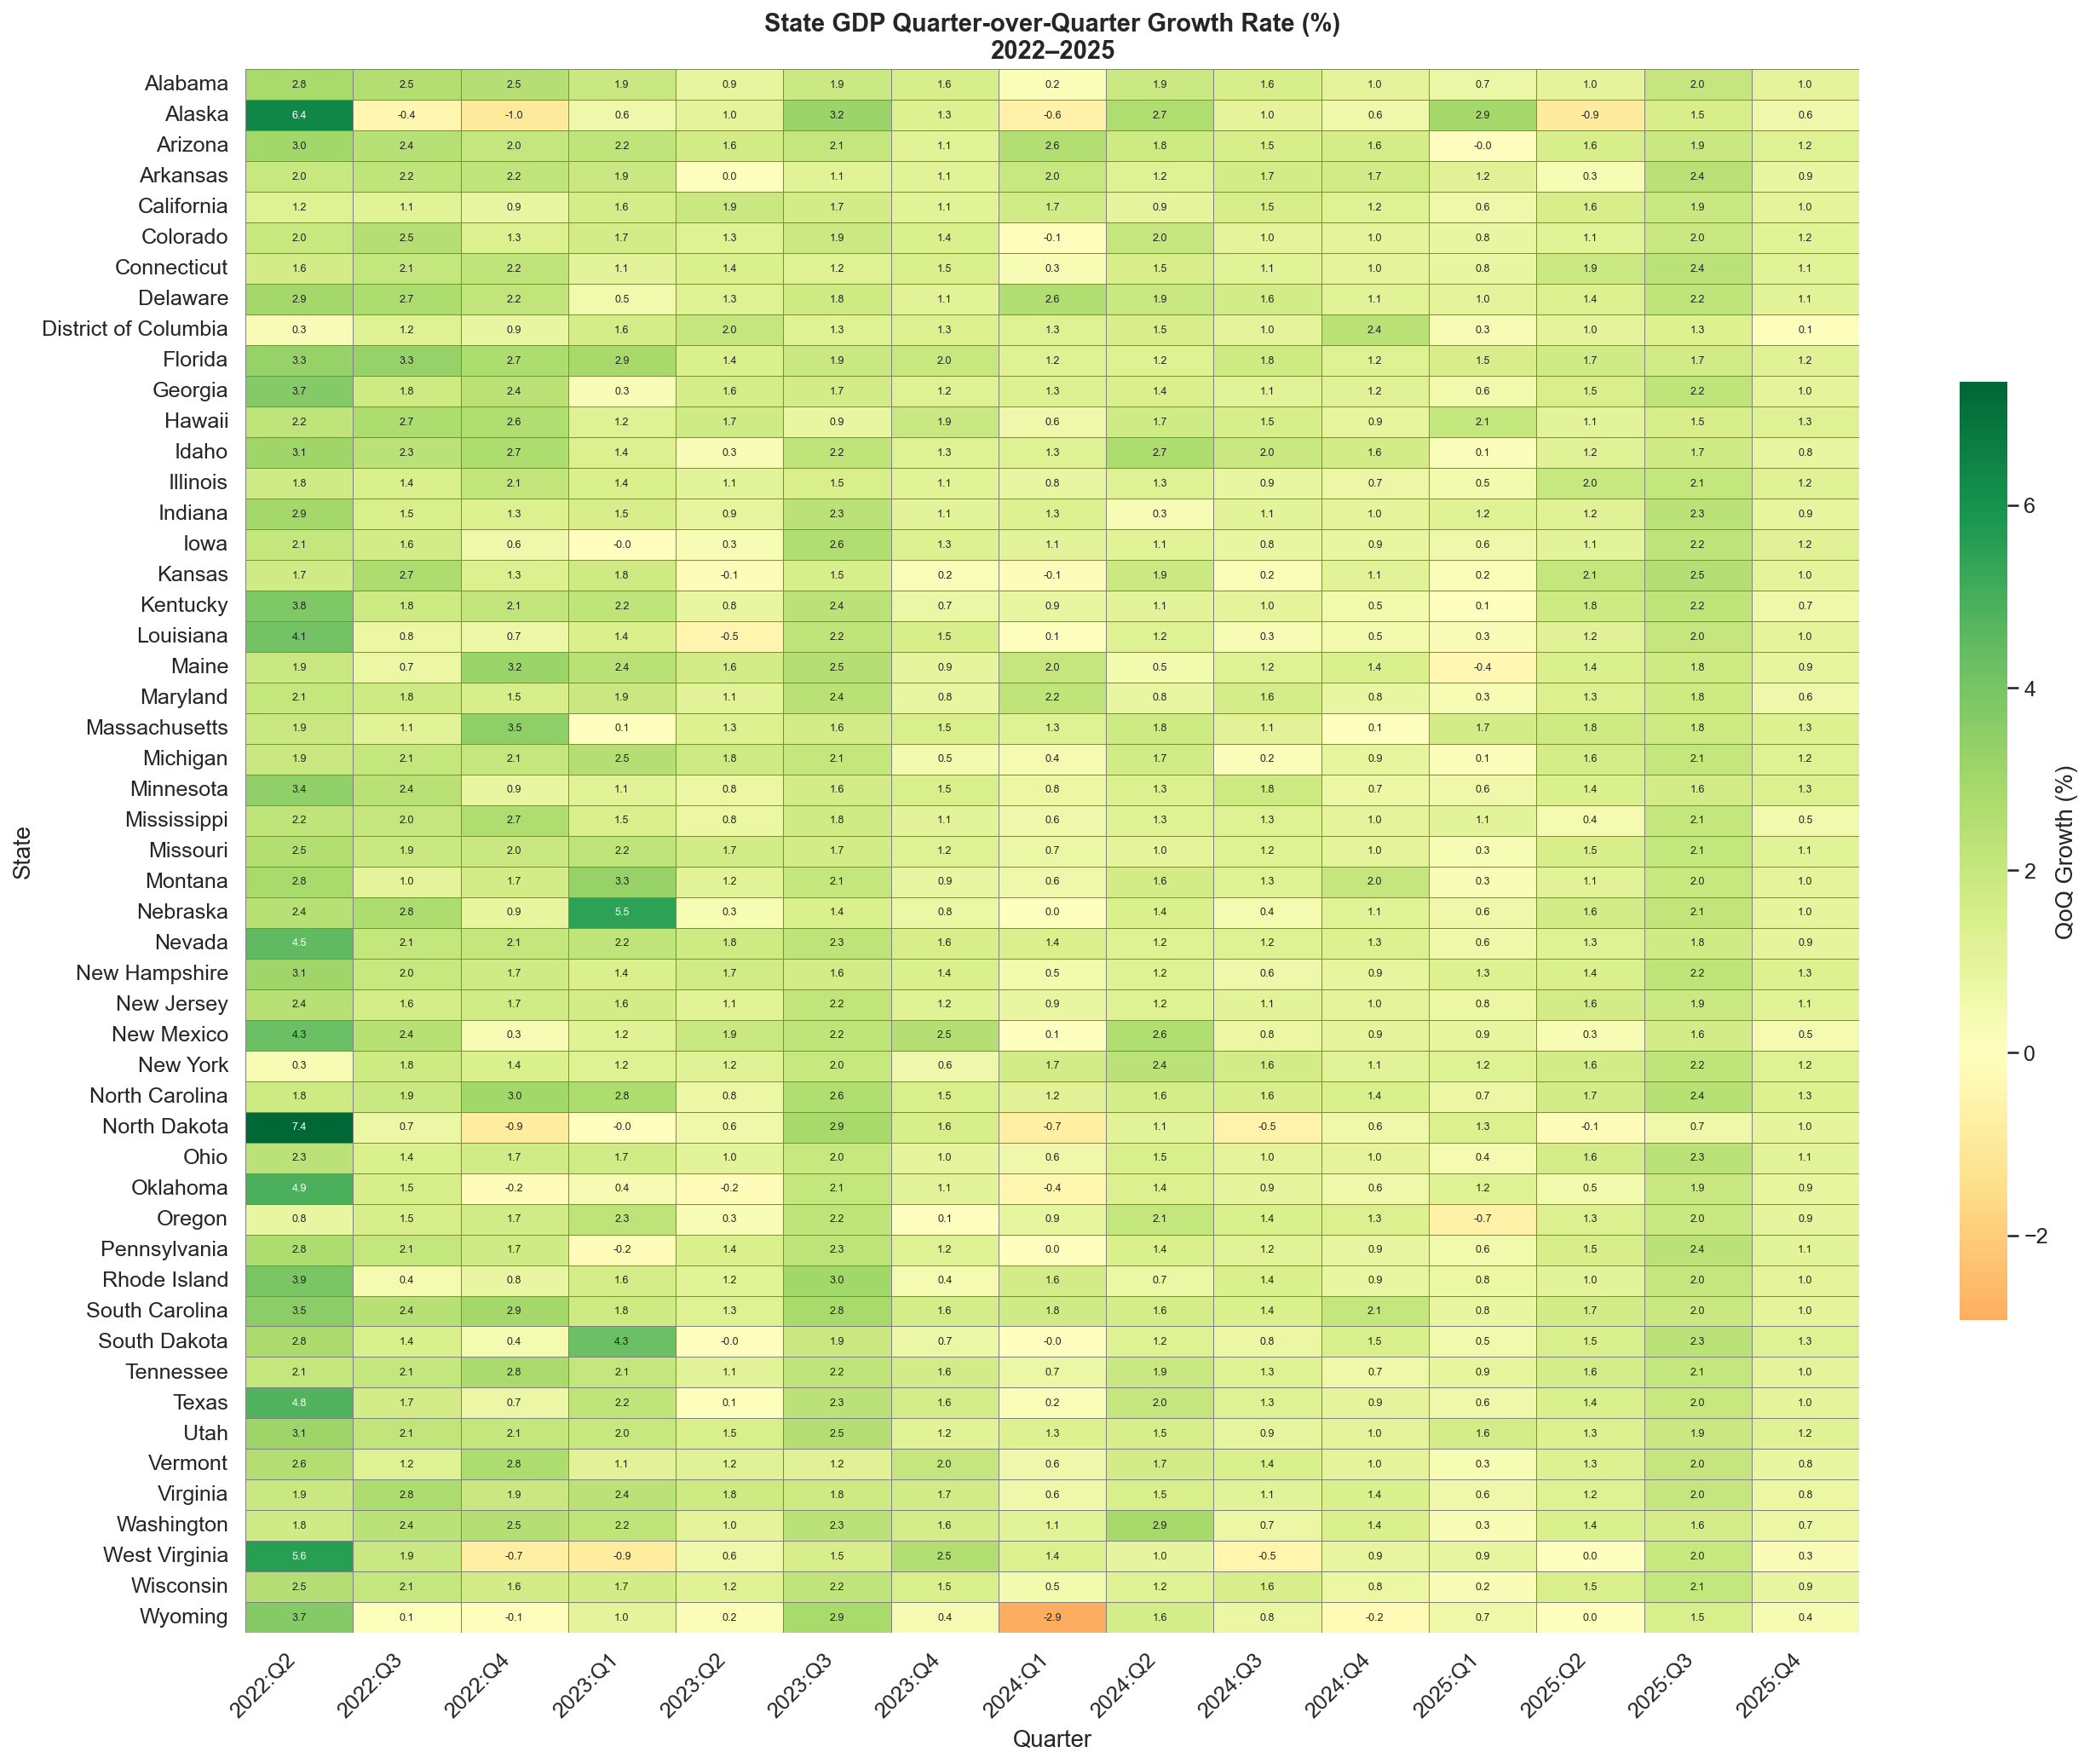

In [18]:
# ── 1-D  State GDP Growth Heatmap ─────────────────────────────────────────
state_qoq_pivot = state_total.pivot_table(
    index="GeoName", columns="Quarter", values="QoQ_Growth")
state_qoq_pivot = state_qoq_pivot.dropna(how="all")
 
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(state_qoq_pivot, ax=ax, cmap="RdYlGn", center=0,
            linewidths=0.3, linecolor="gray",
            cbar_kws={"label": "QoQ Growth (%)", "shrink": 0.6},
            fmt=".1f", annot=True, annot_kws={"size": 6})
ax.set_title("State GDP Quarter-over-Quarter Growth Rate (%)\n2022–2025",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("State")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

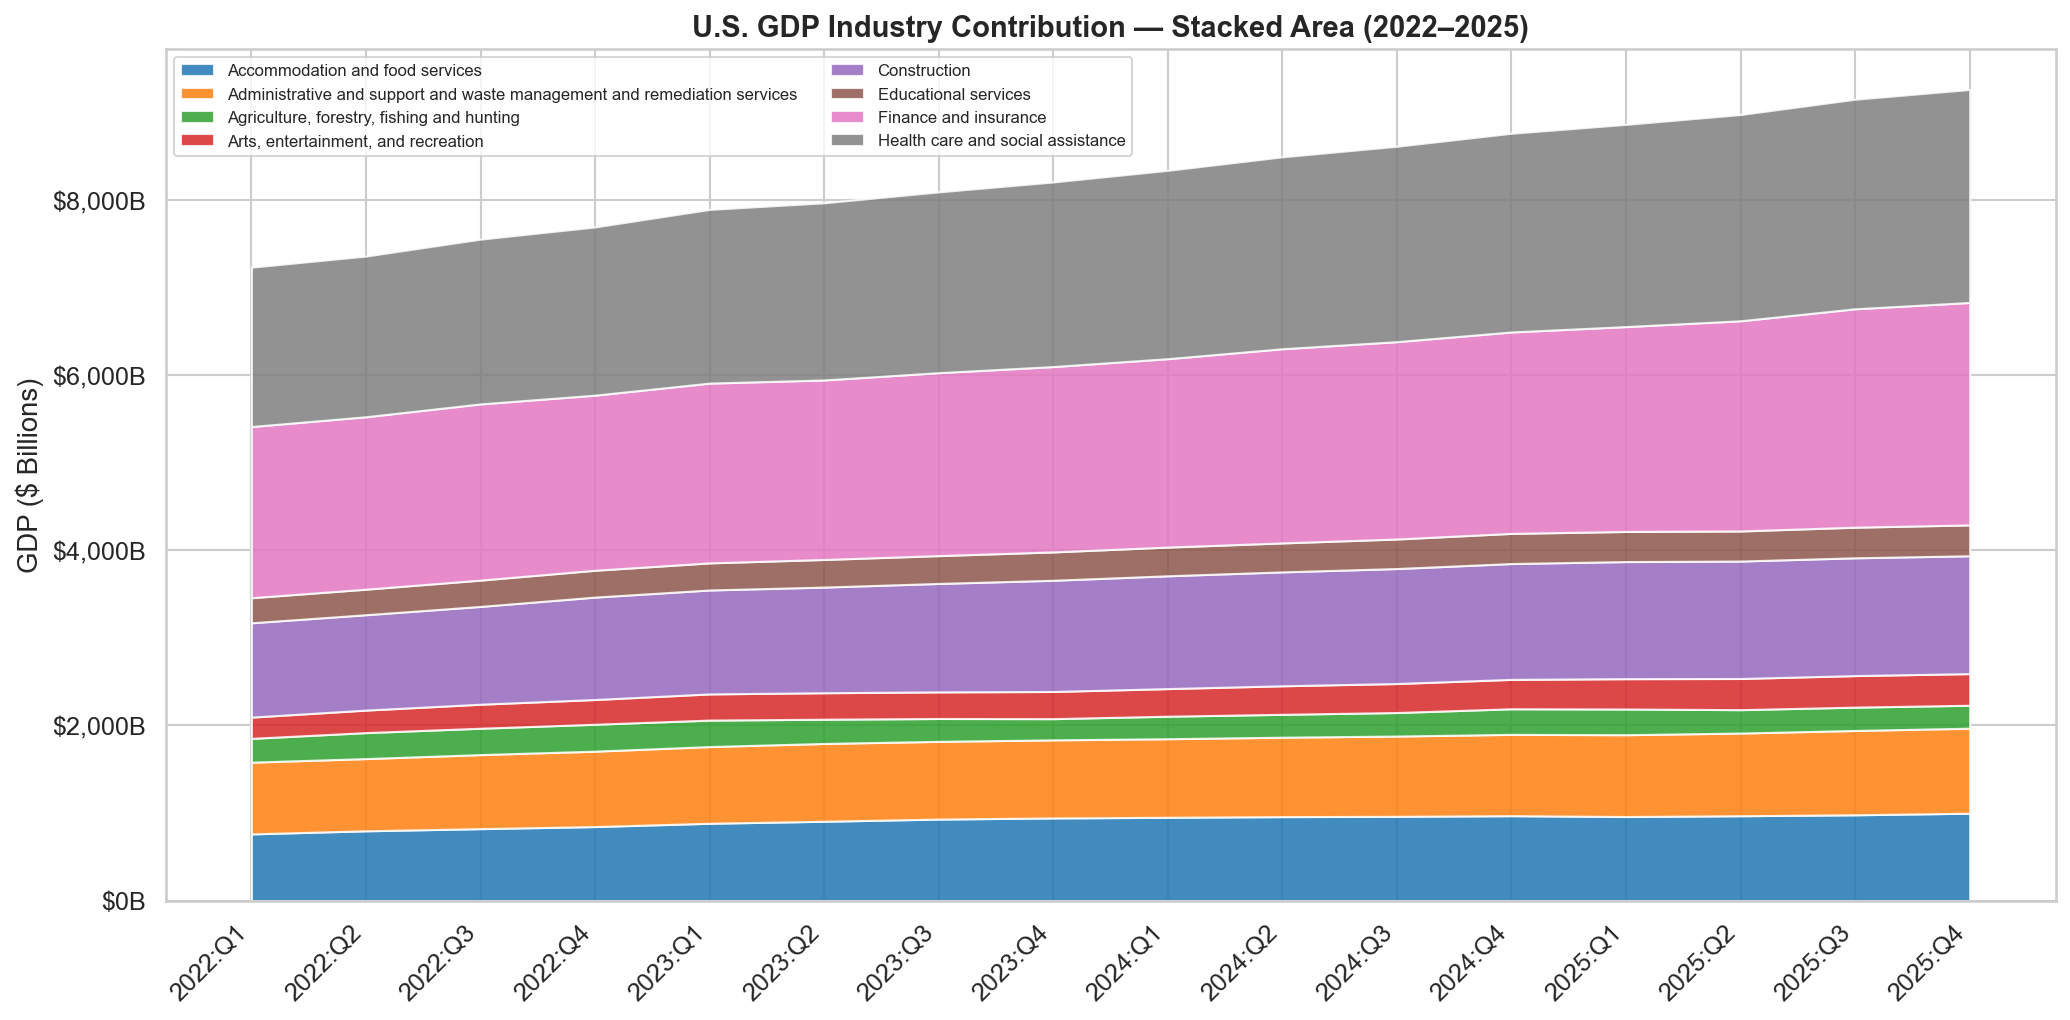

In [19]:
# ── 1-E  Industry Contribution Over Time (Stacked Area) ───────────────────
top_industries = [d for d in us_industry["Description"].unique()
                  if d not in industry_excl][:8]
ind_ts = us_industry[us_industry["Description"].isin(top_industries)].pivot_table(
    index="Quarter", columns="Description", values="GDP_B")
ind_ts.index = pd.CategoricalIndex(ind_ts.index, categories=Q_COLS, ordered=True)
ind_ts = ind_ts.sort_index()
ind_ts.columns = [c.strip() for c in ind_ts.columns]
 
fig, ax = plt.subplots(figsize=(14, 7))
colors_area = plt.cm.tab10.colors[:len(ind_ts.columns)]
ax.stackplot(range(len(ind_ts)), ind_ts.T.values,
             labels=ind_ts.columns, colors=colors_area, alpha=0.85)
ax.set_xticks(range(len(ind_ts)))
ax.set_xticklabels(Q_COLS, rotation=45, ha="right")
ax.set_ylabel("GDP ($ Billions)")
ax.set_title("U.S. GDP Industry Contribution — Stacked Area (2022–2025)",
             fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}B"))
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

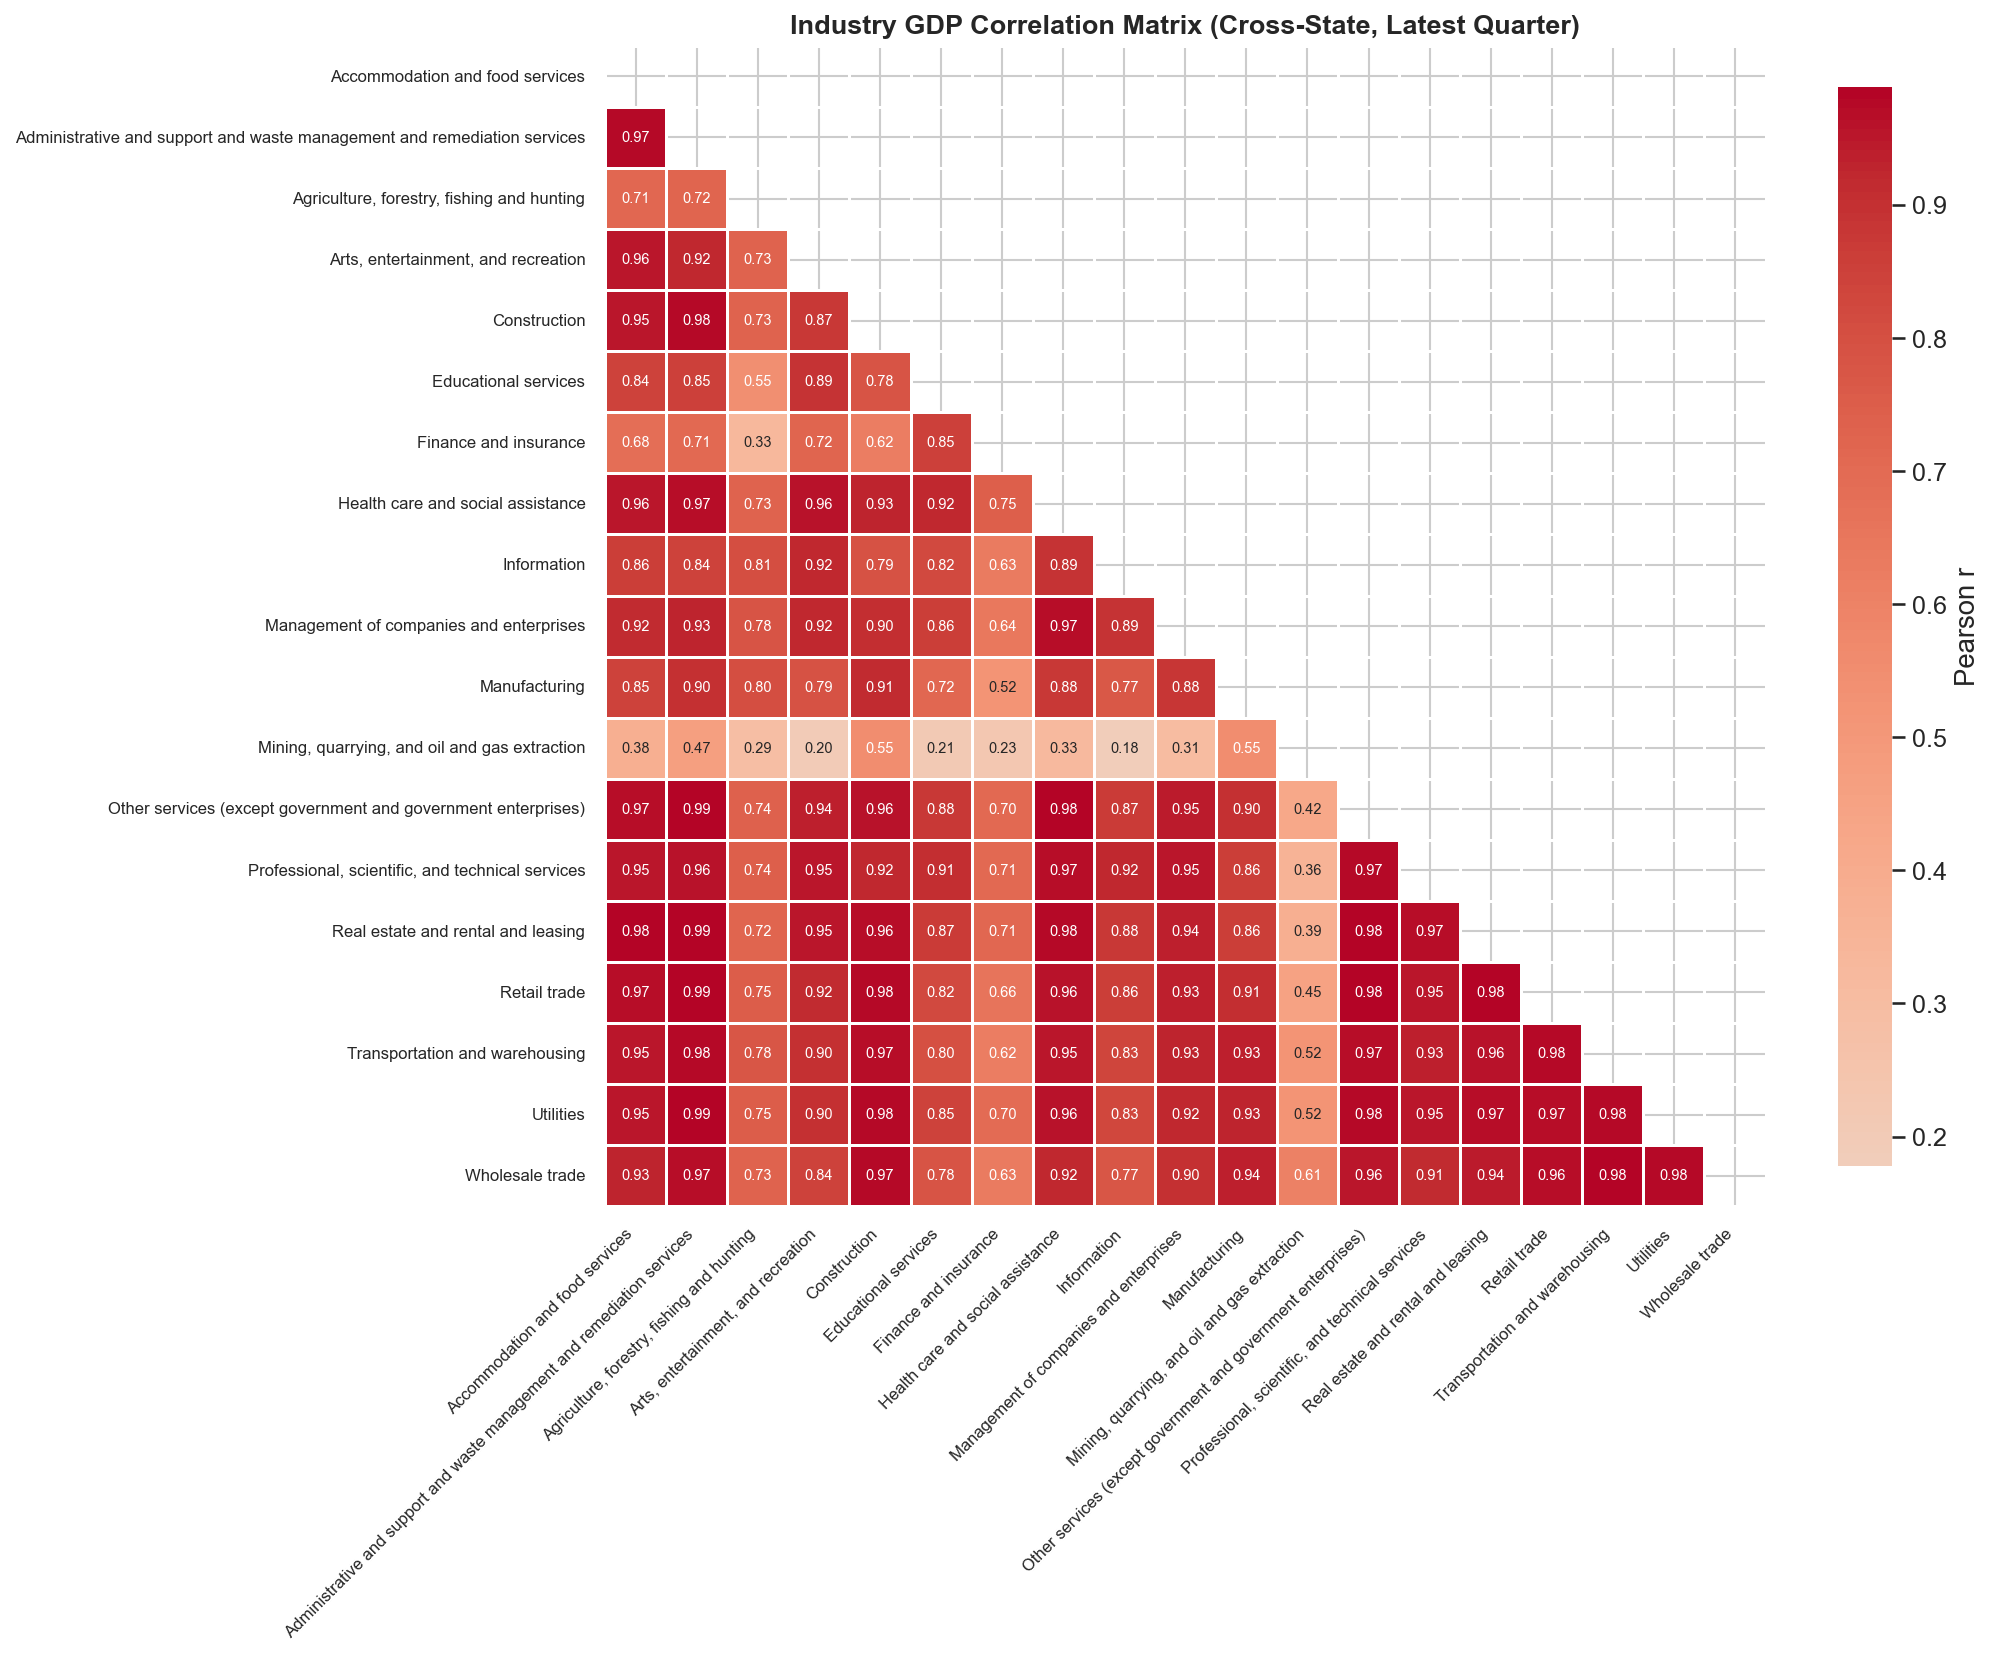

In [60]:
# ── 6-A  Industry-State Correlation Heatmap ───────────────────────────────
industry_pivot = long[
    (long["GeoName"] != "United States *") &
    (~long["GeoName"].str.contains("overseas", case=False)) &
    (long["Quarter"] == latest_q) &
    (~long["Description"].isin(industry_excl))
].pivot_table(index="GeoName", columns="Description", values="GDP_B")
industry_pivot.columns = [c.strip() for c in industry_pivot.columns]
corr_mat = industry_pivot.corr()
 
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, ax=ax, mask=mask, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.5, square=True,
            cbar_kws={"label": "Pearson r", "shrink": 0.8})
ax.set_title("Industry GDP Correlation Matrix (Cross-State, Latest Quarter)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.show()

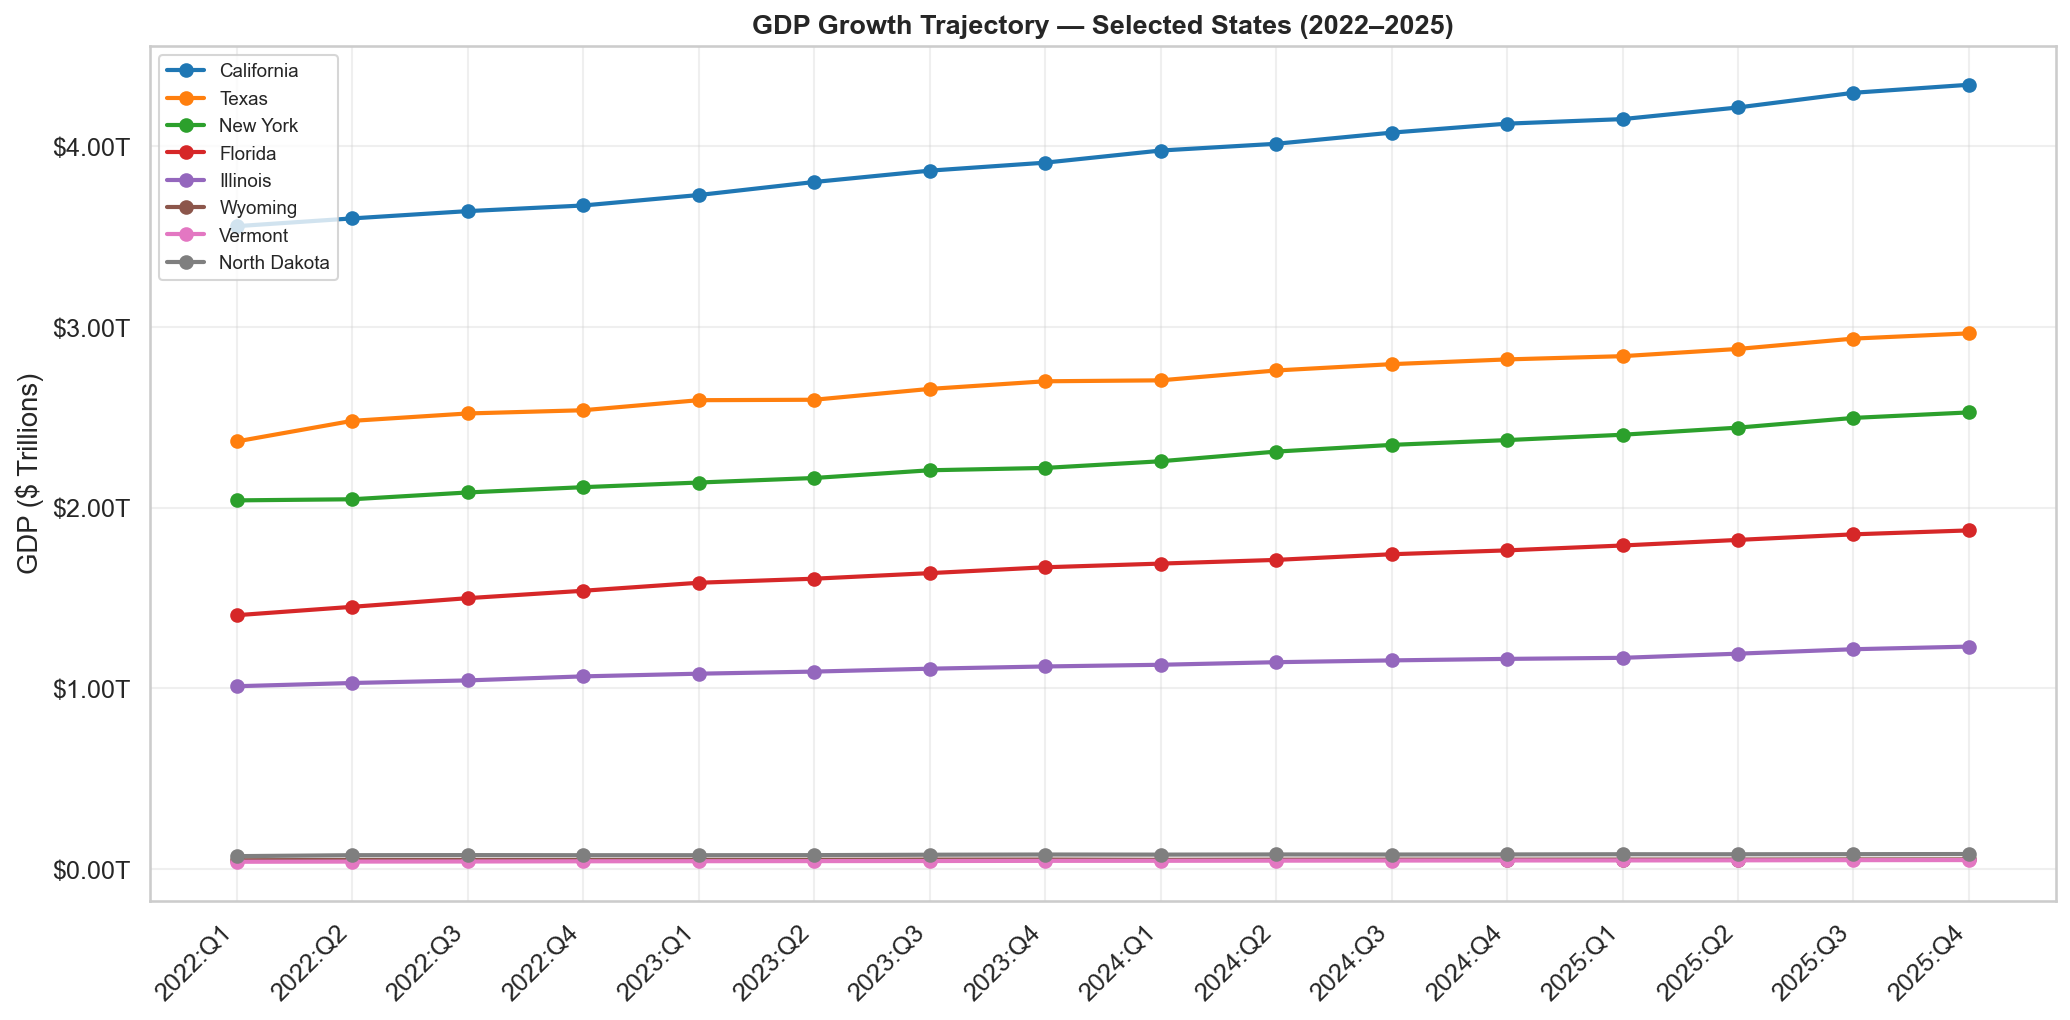

In [61]:
# ── 6-B  GDP Growth Trajectory — Selected States ──────────────────────────
highlight_states = ["California", "Texas", "New York", "Florida", "Illinois",
                    "Wyoming", "Vermont", "North Dakota"]
fig, ax = plt.subplots(figsize=(14, 7))
palette = plt.cm.tab10.colors
 
for i, state in enumerate(highlight_states):
    sdf = state_total[state_total["GeoName"] == state].sort_values("Period")
    growth = sdf["GDP_T"].values
    ax.plot(range(len(Q_COLS)), growth, marker="o", linewidth=2,
            color=palette[i % 10], label=state)
ax.set_xticks(range(len(Q_COLS)))
ax.set_xticklabels(Q_COLS, rotation=45, ha="right")
ax.set_ylabel("GDP ($ Trillions)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:.2f}T"))
ax.set_title("GDP Growth Trajectory — Selected States (2022–2025)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

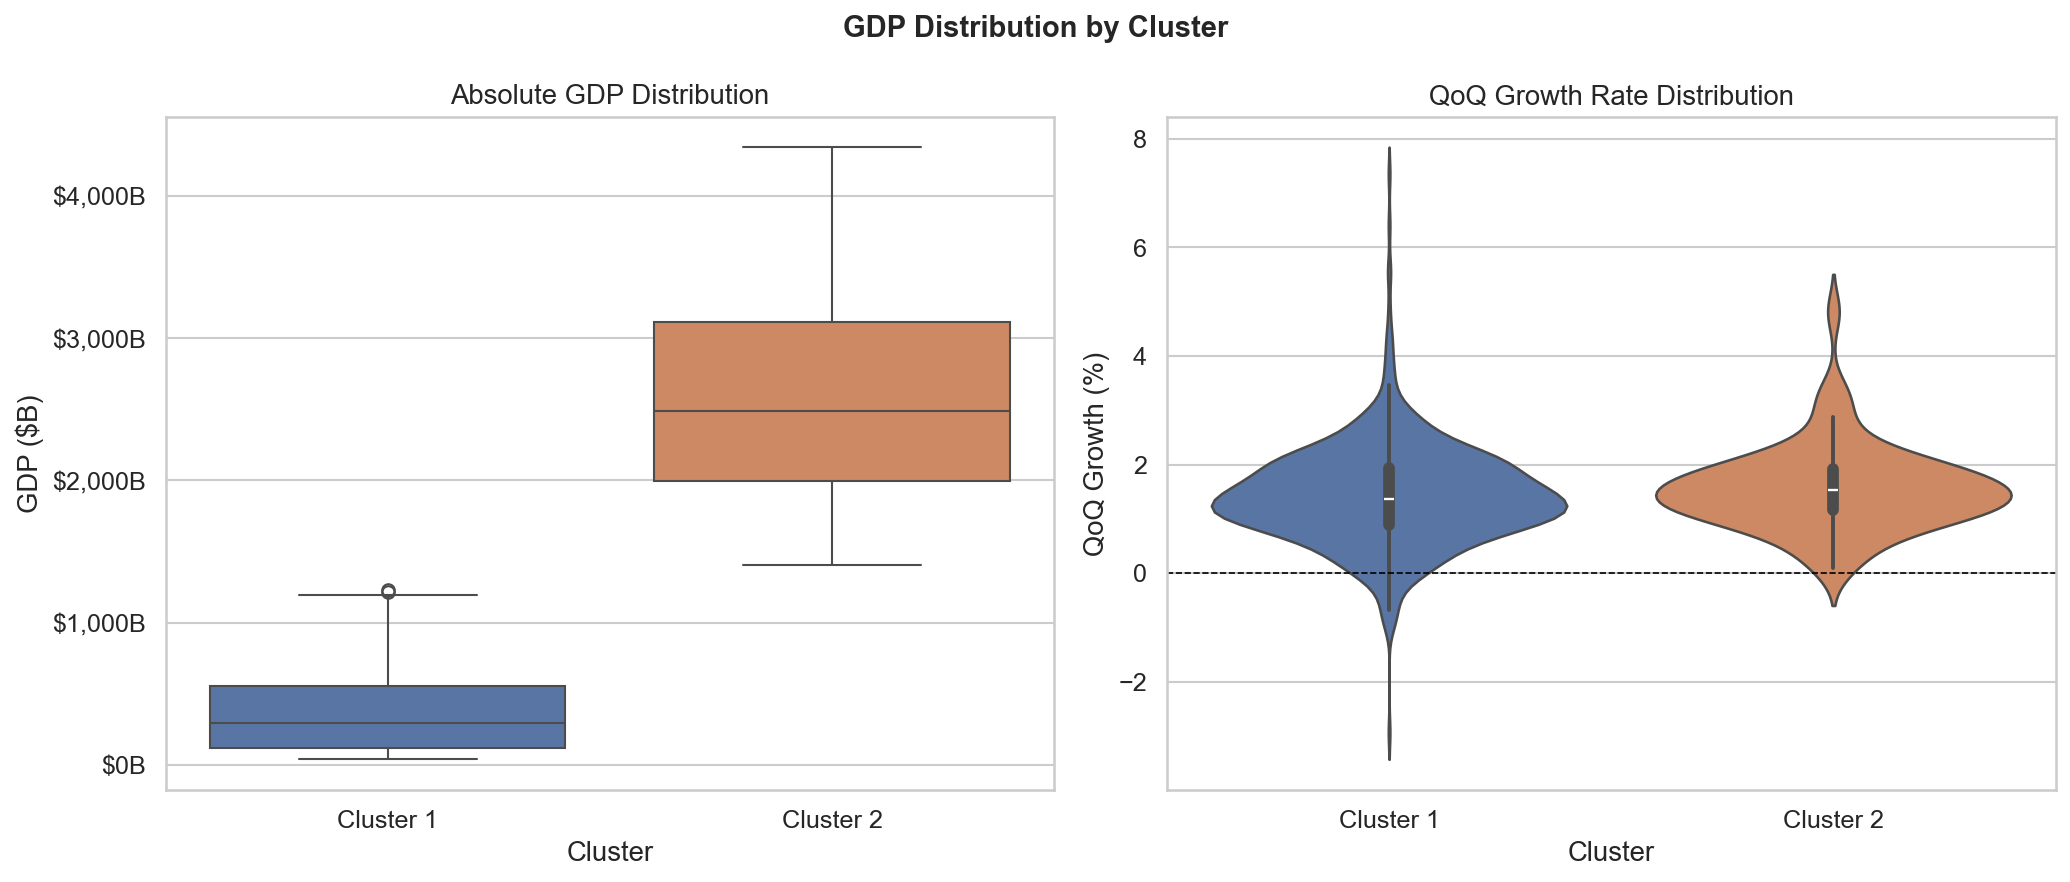

In [62]:
state_total_clust = state_total.copy()
state_total_clust["Cluster"] = state_total_clust["GeoName"].map(
    dict(zip(state_labels, cluster_labels)))
state_total_clust = state_total_clust.dropna(subset=["Cluster"])
state_total_clust["Cluster"] = state_total_clust["Cluster"].astype(int)
state_total_clust["Cluster_Label"] = state_total_clust["Cluster"].apply(lambda x: f"Cluster {x+1}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("GDP Distribution by Cluster", fontsize=14, fontweight="bold")
 
sns.boxplot(data=state_total_clust, x="Cluster_Label", y="GDP_B", ax=axes[0],
            palette=[f"C{i}" for i in range(opt_k)])
axes[0].set_ylabel("GDP ($B)")
axes[0].set_xlabel("Cluster")
axes[0].set_title("Absolute GDP Distribution")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}B"))
 
st_no_outlier = state_total_clust[state_total_clust["QoQ_Growth"].between(-5, 15)]
sns.violinplot(data=st_no_outlier, x="Cluster_Label", y="QoQ_Growth", ax=axes[1],
               palette=[f"C{i}" for i in range(opt_k)], inner="box")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("QoQ Growth (%)")
axes[1].set_xlabel("Cluster")
axes[1].set_title("QoQ Growth Rate Distribution")
 
plt.tight_layout()
plt.show()

Hypothesis Testing

In [21]:
results_ht = []

# ── 2-A  Test 1: Did US GDP grow significantly from 2022 to 2025? ─────────
gdp_2022 = us_total[us_total["Year"] == 2022]["GDP_M"].values
gdp_2025 = us_total[us_total["Year"] == 2025]["GDP_M"].values
 
t_stat, p_val = stats.ttest_ind(gdp_2025, gdp_2022)
print(f"\n[TEST 1] Independent t-test: US GDP 2022 vs 2025")
print(f"  H0: Mean GDP in 2025 = Mean GDP in 2022")
print(f"  H1: Mean GDP in 2025 > Mean GDP in 2022 (one-tailed)")
print(f"  2022 mean: ${np.mean(gdp_2022)/1e6:.3f}T  |  2025 mean: ${np.mean(gdp_2025)/1e6:.3f}T")
print(f"  t-statistic: {t_stat:.4f}  |  p-value (two-tailed): {p_val:.6f}")
print(f"  p-value (one-tailed): {p_val/2:.6f}")
conclusion = "REJECT H0 — GDP significantly higher in 2025" if p_val/2 < 0.05 else "FAIL TO REJECT H0"
print(f"  Conclusion (α=0.05): {conclusion}")
results_ht.append({"Test": "t-test: 2022 vs 2025 GDP", "Statistic": t_stat,
                   "p-value": p_val/2, "Conclusion": conclusion})


[TEST 1] Independent t-test: US GDP 2022 vs 2025
  H0: Mean GDP in 2025 = Mean GDP in 2022
  H1: Mean GDP in 2025 > Mean GDP in 2022 (one-tailed)
  2022 mean: $26.055T  |  2025 mean: $30.762T
  t-statistic: 10.4830  |  p-value (two-tailed): 0.000044
  p-value (one-tailed): 0.000022
  Conclusion (α=0.05): REJECT H0 — GDP significantly higher in 2025


In [22]:
# ── Test 2: Paired t-test (Q1 vs Q3 seasonality) ────────────────────
q1_vals = state_total[state_total["Qtr"] == 1]["GDP_M"].values
q3_vals = state_total[state_total["Qtr"] == 3]["GDP_M"].values
 
t2, p2 = stats.ttest_rel(q3_vals[:min(len(q1_vals),len(q3_vals))],
                          q1_vals[:min(len(q1_vals),len(q3_vals))])
print(f"\n[TEST 2] Paired t-test: Seasonal Effect Q1 vs Q3 (State GDP)")
print(f"  H0: No seasonal difference between Q1 and Q3")
print(f"  Q1 mean: ${np.mean(q1_vals)/1e6:.3f}T  |  Q3 mean: ${np.mean(q3_vals)/1e6:.3f}T")
print(f"  t-statistic: {t2:.4f}  |  p-value: {p2:.6f}")
c2 = "REJECT H0 — Significant seasonal difference Q1 vs Q3" if p2 < 0.05 else "FAIL TO REJECT H0"
print(f"  Conclusion (α=0.05): {c2}")
results_ht.append({"Test": "Paired t-test: Q1 vs Q3", "Statistic": t2, "p-value": p2, "Conclusion": c2})


[TEST 2] Paired t-test: Seasonal Effect Q1 vs Q3 (State GDP)
  H0: No seasonal difference between Q1 and Q3
  Q1 mean: $0.542T  |  Q3 mean: $0.561T
  t-statistic: 10.7819  |  p-value: 0.000000
  Conclusion (α=0.05): REJECT H0 — Significant seasonal difference Q1 vs Q3


In [23]:
# ── Test 3: One-Way ANOVA — GDP by Quarter (Seasonality) ────────────
groups_by_qtr = [state_total[state_total["Qtr"] == q]["GDP_M"].dropna().values
                 for q in [1, 2, 3, 4]]
f3, p3 = stats.f_oneway(*groups_by_qtr)
print(f"\n[TEST 3] One-Way ANOVA: GDP by Quarter (Q1/Q2/Q3/Q4)")
print(f"  H0: Mean GDP is equal across all four quarters")
print(f"  F-statistic: {f3:.4f}  |  p-value: {p3:.6f}")
c3 = "REJECT H0 — Significant difference across quarters" if p3 < 0.05 else "FAIL TO REJECT H0"
print(f"  Conclusion (α=0.05): {c3}")
results_ht.append({"Test": "One-Way ANOVA: GDP by Quarter", "Statistic": f3, "p-value": p3, "Conclusion": c3})


[TEST 3] One-Way ANOVA: GDP by Quarter (Q1/Q2/Q3/Q4)
  H0: Mean GDP is equal across all four quarters
  F-statistic: 0.0501  |  p-value: 0.985182
  Conclusion (α=0.05): FAIL TO REJECT H0


In [24]:
# ── Test 4: Kruskal-Wallis — Non-parametric ANOVA (top 5 states) ────
top5_states = state_latest.head(5)["GeoName"].tolist()
groups_states = [state_total[state_total["GeoName"] == s]["GDP_M"].dropna().values
                 for s in top5_states]
kw_stat, kw_p = stats.kruskal(*groups_states)
print(f"\n[TEST 4] Kruskal-Wallis H-test: GDP distribution among top-5 states")
print(f"  States: {top5_states}")
print(f"  H0: All states have the same GDP distribution")
print(f"  H-statistic: {kw_stat:.4f}  |  p-value: {kw_p:.6f}")
c4 = "REJECT H0 — States differ significantly in GDP" if kw_p < 0.05 else "FAIL TO REJECT H0"
print(f"  Conclusion (α=0.05): {c4}")
results_ht.append({"Test": "Kruskal-Wallis: Top-5 States", "Statistic": kw_stat, "p-value": kw_p, "Conclusion": c4})


[TEST 4] Kruskal-Wallis H-test: GDP distribution among top-5 states
  States: ['California', 'Texas', 'New York', 'Florida', 'Illinois']
  H0: All states have the same GDP distribution
  H-statistic: 75.3926  |  p-value: 0.000000
  Conclusion (α=0.05): REJECT H0 — States differ significantly in GDP


In [25]:
# ── Test 5: Chi-Square — GDP Growth quartile vs quarter ──────────────
state_total2 = state_total.dropna(subset=["QoQ_Growth"]).copy()
state_total2["Growth_Cat"] = pd.qcut(state_total2["QoQ_Growth"], q=4,
                                      labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])
contingency = pd.crosstab(state_total2["Qtr"], state_total2["Growth_Cat"])
chi2, chi_p, dof, _ = stats.chi2_contingency(contingency)
print(f"\n[TEST 5] Chi-Square Test: GDP Growth Category vs Fiscal Quarter")
print(f"  H0: GDP growth category is independent of fiscal quarter")
print(f"  Chi² = {chi2:.4f}  |  df = {dof}  |  p-value = {chi_p:.6f}")
c5 = "REJECT H0 — Growth category depends on quarter" if chi_p < 0.05 else "FAIL TO REJECT H0"
print(f"  Conclusion (α=0.05): {c5}")
results_ht.append({"Test": "Chi-Square: Growth Category × Quarter", "Statistic": chi2, "p-value": chi_p, "Conclusion": c5})


[TEST 5] Chi-Square Test: GDP Growth Category vs Fiscal Quarter
  H0: GDP growth category is independent of fiscal quarter
  Chi² = 143.6057  |  df = 9  |  p-value = 0.000000
  Conclusion (α=0.05): REJECT H0 — Growth category depends on quarter


In [26]:
# ── Post-hoc: Tukey HSD after ANOVA ─────────────────────────────────
print(f"\n[POST-HOC] Tukey HSD — Pairwise Quarter Comparisons")
tukey_data   = state_total[["GDP_M", "Qtr"]].dropna()
tukey_result = pairwise_tukeyhsd(tukey_data["GDP_M"], tukey_data["Qtr"], alpha=0.05)
print(tukey_result.summary())


[POST-HOC] Tukey HSD — Pairwise Quarter Comparisons
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2  meandiff  p-adj     lower        upper    reject
---------------------------------------------------------------
     1      2  8821.6176 0.9993 -172739.2846 190382.5199  False
     1      3  18563.427 0.9936 -162997.4753 200124.3292  False
     1      4 25506.5123 0.9838   -156054.39 207067.4145  False
     2      3  9741.8093 0.9991  -171819.093 191302.7116  False
     2      4 16684.8946 0.9953 -164876.0077 198245.7969  False
     3      4  6943.0853 0.9997  -174617.817 188503.9876  False
---------------------------------------------------------------


In [27]:
# ── ADF Stationarity Test on US GDP ──────────────────────────────────
print(f"\n[TEST 6] Augmented Dickey-Fuller: US National GDP Stationarity")
adf_result = adfuller(us_total["GDP_M"].dropna(), autolag="AIC")
print(f"  ADF Statistic: {adf_result[0]:.4f}")
print(f"  p-value:       {adf_result[1]:.4f}")
for k, v in adf_result[4].items():
    print(f"  Critical Value ({k}): {v:.4f}")
if adf_result[1] > 0.05:
    print("  → Series is NON-STATIONARY (unit root present) — differencing needed for ARIMA")
else:
    print("  → Series is STATIONARY")


[TEST 6] Augmented Dickey-Fuller: US National GDP Stationarity
  ADF Statistic: -0.9743
  p-value:       0.7625
  Critical Value (1%): -4.4731
  Critical Value (5%): -3.2899
  Critical Value (10%): -2.7724
  → Series is NON-STATIONARY (unit root present) — differencing needed for ARIMA


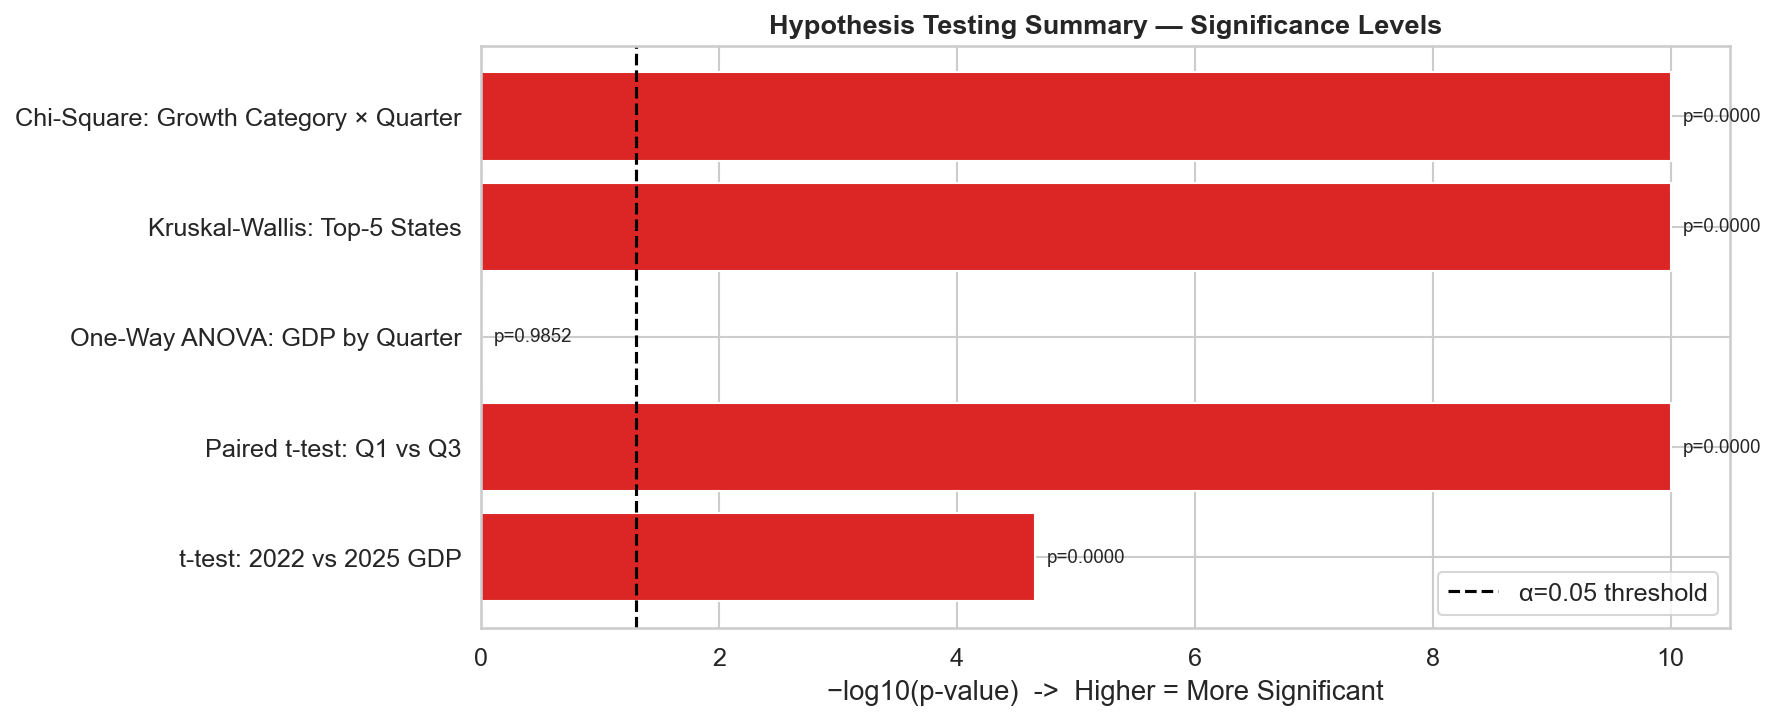

In [30]:
df_ht = pd.DataFrame(results_ht)
fig, ax = plt.subplots(figsize=(12, 5))
colors_ht = [HIGHLIGHT if p < 0.05 else NEUTRAL for p in df_ht["p-value"]]
bars = ax.barh(df_ht["Test"], -np.log10(df_ht["p-value"] + 1e-10), color=colors_ht)
ax.axvline(-np.log10(0.05), color="black", linestyle="--", linewidth=1.5, label="α=0.05 threshold")
ax.set_xlabel("−log10(p-value)  ->  Higher = More Significant")
ax.set_title("Hypothesis Testing Summary — Significance Levels", fontsize=13, fontweight="bold")
ax.legend()
for bar, row in zip(bars, df_ht.itertuples()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"p={row._3:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Time Series Modeling

In [31]:
ts_vals = us_total["GDP_M"].values.astype(float)
n_train = 12   # 12 quarters for training
n_test  = 4    # 4 quarters for testing (2025)
train   = ts_vals[:n_train]
test    = ts_vals[n_train:n_train + n_test]
labels  = Q_COLS
 
print(f"Train: {Q_COLS[:n_train]}")
print(f"Test:  {Q_COLS[n_train:n_train+n_test]}")
 
ts_results = {}

Train: ['2022:Q1', '2022:Q2', '2022:Q3', '2022:Q4', '2023:Q1', '2023:Q2', '2023:Q3', '2023:Q4', '2024:Q1', '2024:Q2', '2024:Q3', '2024:Q4']
Test:  ['2025:Q1', '2025:Q2', '2025:Q3', '2025:Q4']


In [32]:
# ── Holt-Winters (Triple Exponential Smoothing) ─────────────────────
hw_model = ExponentialSmoothing(train, trend="add", seasonal=None,
                                 initialization_method="estimated")
hw_fit   = hw_model.fit(optimized=True)
hw_pred  = hw_fit.forecast(n_test)
hw_mae   = mean_absolute_error(test, hw_pred)
hw_rmse  = np.sqrt(mean_squared_error(test, hw_pred))
hw_r2    = r2_score(test, hw_pred)
ts_results["Holt-Winters"] = {"pred": hw_pred, "MAE": hw_mae, "RMSE": hw_rmse, "R²": hw_r2}
print(f"\nHolt-Winters  | MAE: ${hw_mae/1e6:.3f}T | RMSE: ${hw_rmse/1e6:.3f}T | R²: {hw_r2:.4f}")


Holt-Winters  | MAE: $0.159T | RMSE: $0.180T | R²: 0.8871


C:\Users\Lehma\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [33]:
# ──ARIMA (first-difference for stationarity) ────────────────────────
try:
    arima_model = SARIMAX(train, order=(1, 1, 1), trend="n",
                           enforce_stationarity=False, enforce_invertibility=False)
    arima_fit   = arima_model.fit(disp=False)
    arima_pred  = arima_fit.forecast(n_test)
    arima_mae   = mean_absolute_error(test, arima_pred)
    arima_rmse  = np.sqrt(mean_squared_error(test, arima_pred))
    arima_r2    = r2_score(test, arima_pred)
    ts_results["ARIMA(1,1,1)"] = {"pred": arima_pred, "MAE": arima_mae,
                                   "RMSE": arima_rmse, "R²": arima_r2}
    print(f"ARIMA(1,1,1)  | MAE: ${arima_mae/1e6:.3f}T | RMSE: ${arima_rmse/1e6:.3f}T | R²: {arima_r2:.4f}")
except Exception as e:
    print(f"ARIMA failed: {e}")

ARIMA(1,1,1)  | MAE: $0.327T | RMSE: $0.405T | R²: 0.4269


In [34]:
# ── Linear Trend Extrapolation (baseline) ────────────────────────────
x_train = np.arange(n_train)
x_test  = np.arange(n_train, n_train + n_test)
slope, intercept, *_ = stats.linregress(x_train, train)
trend_pred = slope * x_test + intercept
trend_mae  = mean_absolute_error(test, trend_pred)
trend_rmse = np.sqrt(mean_squared_error(test, trend_pred))
trend_r2   = r2_score(test, trend_pred)
ts_results["Linear Trend"] = {"pred": trend_pred, "MAE": trend_mae,
                               "RMSE": trend_rmse, "R²": trend_r2}
print(f"Linear Trend  | MAE: ${trend_mae/1e6:.3f}T | RMSE: ${trend_rmse/1e6:.3f}T | R²: {trend_r2:.4f}")

Linear Trend  | MAE: $0.224T | RMSE: $0.243T | R²: 0.7927


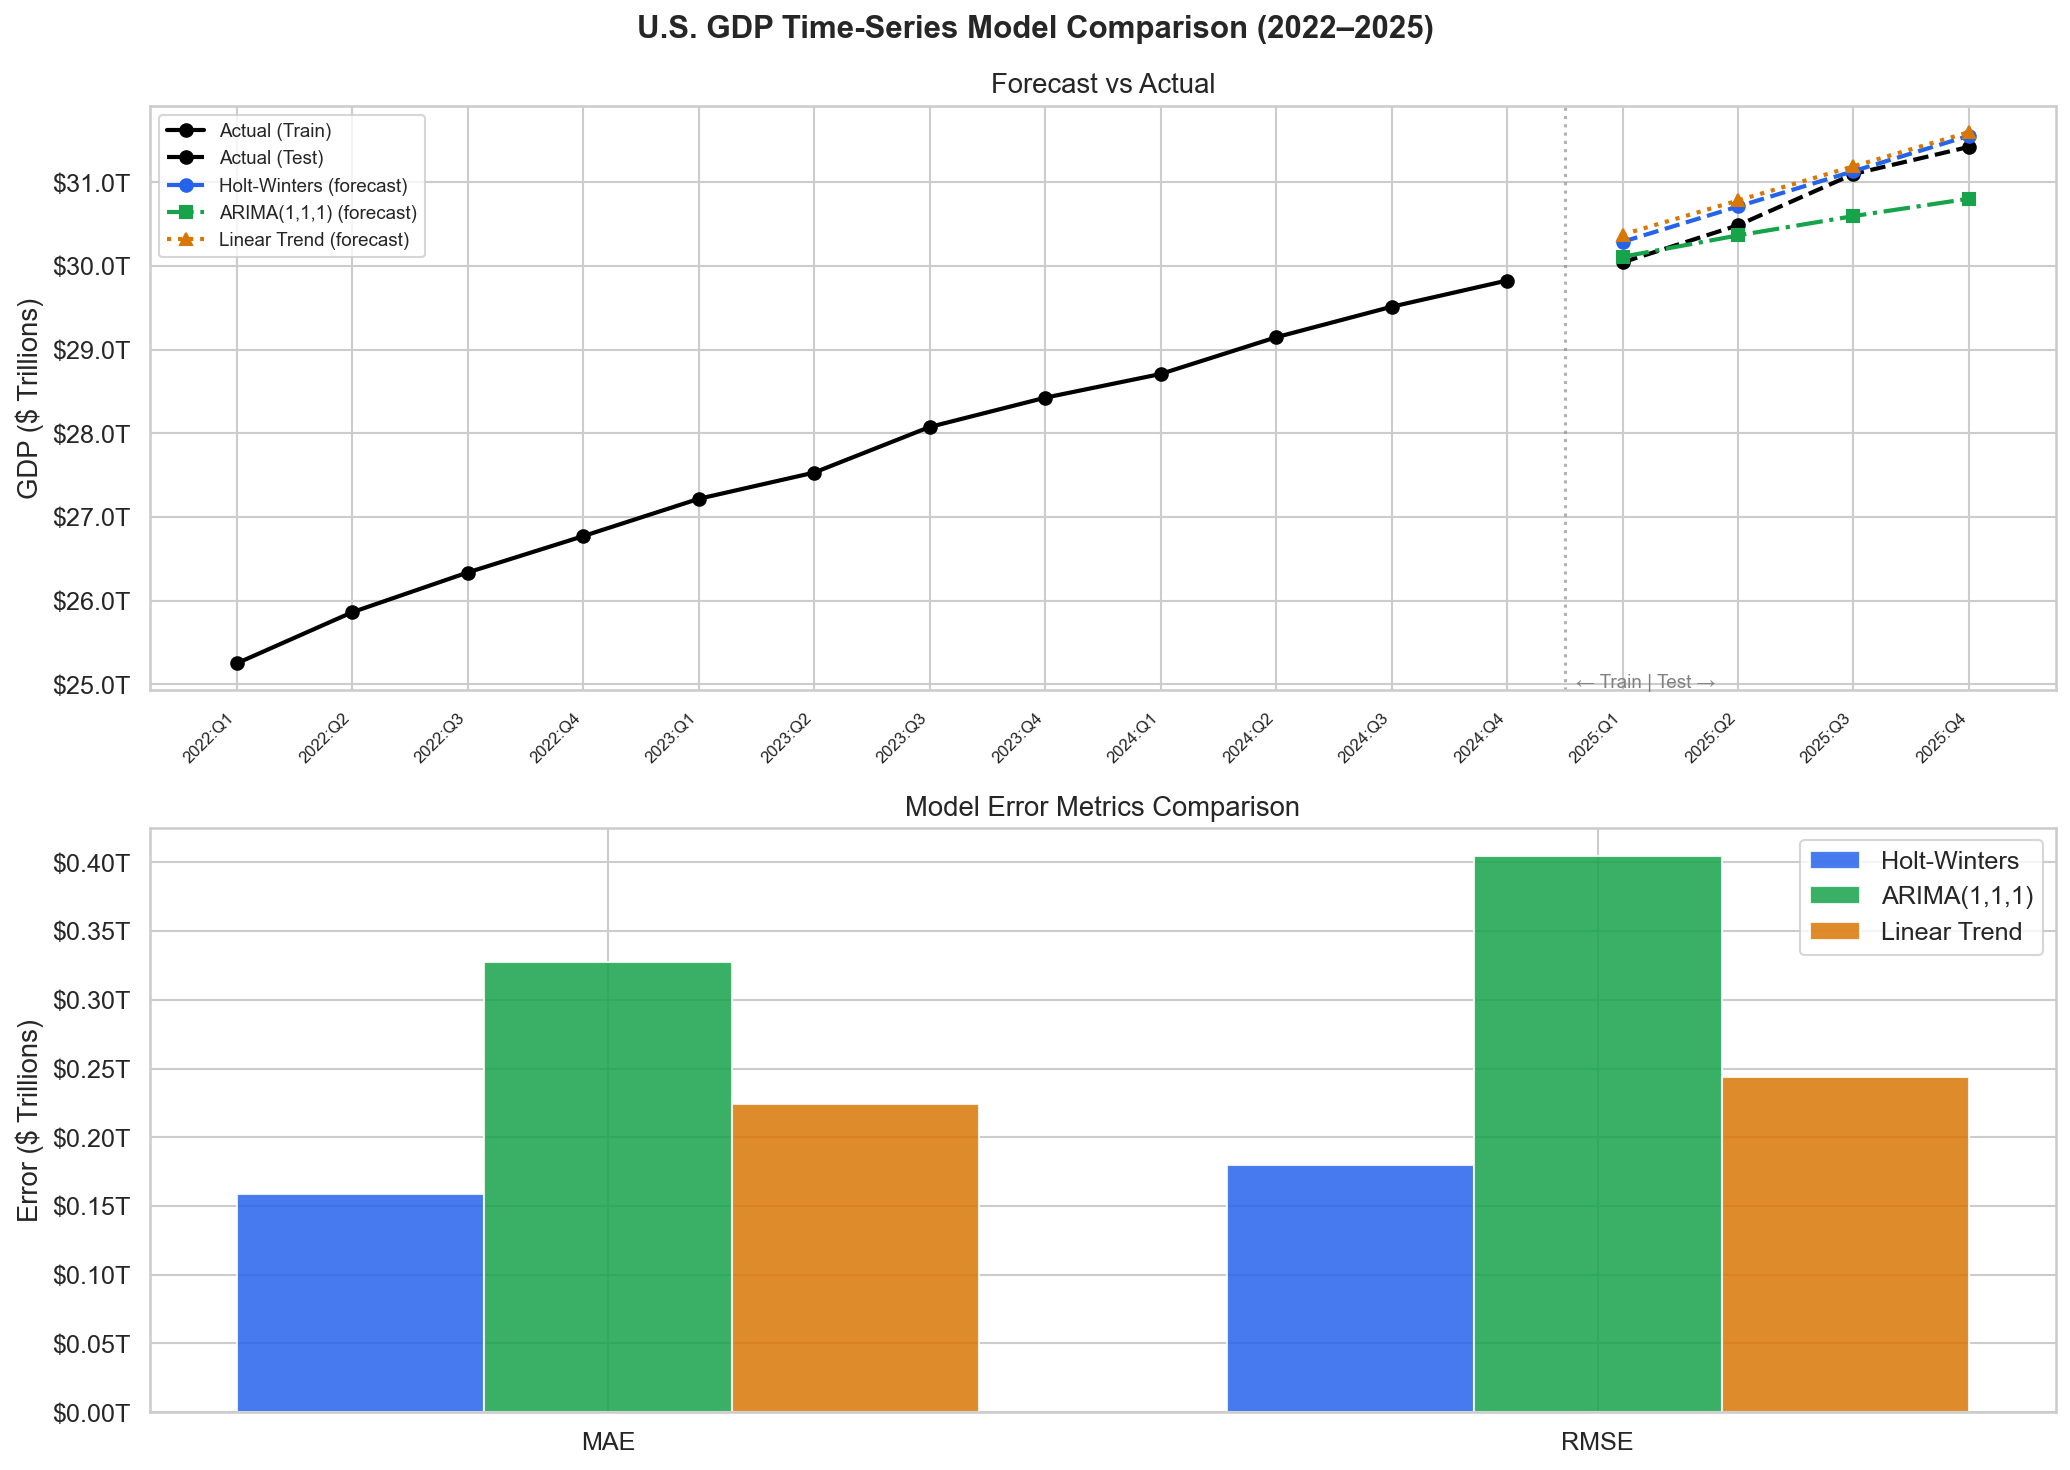

In [35]:
# ── Time-Series Comparison Plot ────────────────────────────────────────────
xs_all = list(range(len(Q_COLS[:n_train + n_test])))
xs_train = xs_all[:n_train]
xs_test  = xs_all[n_train:n_train + n_test]
 
model_styles = {
    "Holt-Winters":  (ACCENT,    "--", "o"),
    "ARIMA(1,1,1)":  ("#16A34A", "-.", "s"),
    "Linear Trend":  ("#D97706", ":",  "^"),
}
 
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("U.S. GDP Time-Series Model Comparison (2022–2025)", fontsize=15, fontweight="bold")
 
ax = axes[0]
ax.plot(xs_train, train / 1e6, color="black", linewidth=2, marker="o", label="Actual (Train)")
ax.plot(xs_test,  test  / 1e6, color="black", linewidth=2, marker="o", linestyle="--", label="Actual (Test)")
for name, res in ts_results.items():
    clr, ls, mk = model_styles.get(name, (NEUTRAL, "-", "x"))
    ax.plot(xs_test, np.array(res["pred"]) / 1e6, color=clr, linestyle=ls,
            marker=mk, linewidth=2, label=f"{name} (forecast)")
ax.axvline(n_train - 0.5, color="gray", linestyle=":", alpha=0.6)
ax.text(n_train - 0.4, ax.get_ylim()[0] * 1.001, "← Train | Test →",
        color="gray", fontsize=9)
ax.set_ylabel("GDP ($ Trillions)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:.1f}T"))
ax.set_xticks(xs_all)
ax.set_xticklabels(Q_COLS[:n_train + n_test], rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=9)
ax.set_title("Forecast vs Actual")
 
ax2 = axes[1]
metrics = ["MAE", "RMSE"]
x_pos = np.arange(len(metrics))
width = 0.25
for i, (name, res) in enumerate(ts_results.items()):
    clr = list(model_styles.values())[i][0]
    vals = [res["MAE"] / 1e6, res["RMSE"] / 1e6]
    ax2.bar(x_pos + i * width, vals, width, label=name, color=clr, alpha=0.85)
ax2.set_xticks(x_pos + width)
ax2.set_xticklabels(metrics)
ax2.set_ylabel("Error ($ Trillions)")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:.2f}T"))
ax2.set_title("Model Error Metrics Comparison")
ax2.legend()
 
plt.tight_layout()
plt.show()

In [36]:
print("\nTime-Series Model Summary:")
print(f"{'Model':<20} {'MAE ($B)':>10} {'RMSE ($B)':>10} {'R²':>8}")
print("-" * 52)
for name, res in ts_results.items():
    print(f"{name:<20} {res['MAE']/1e3:>10.1f} {res['RMSE']/1e3:>10.1f} {res['R²']:>8.4f}")
best_ts = min(ts_results, key=lambda k: ts_results[k]["RMSE"])
print(f"\n→ Best Time-Series Model: {best_ts} (lowest RMSE)")


Time-Series Model Summary:
Model                  MAE ($B)  RMSE ($B)       R²
----------------------------------------------------
Holt-Winters              159.0      179.7   0.8871
ARIMA(1,1,1)              327.5      404.8   0.4269
Linear Trend              223.9      243.5   0.7927

→ Best Time-Series Model: Holt-Winters (lowest RMSE)


Machine Learning Models

In [39]:
n_train, n_test = 12, 4
train, test = ts_vals[:n_train], ts_vals[n_train:n_train + n_test]
 
# ML feature matrix: lag quarters → predict latest quarter
latest_q    = Q_COLS[-1]
feature_qs  = Q_COLS[:-1]
ml_data     = state_total.pivot_table(index="GeoName", columns="Quarter",
                                       values="GDP_M")[Q_COLS].dropna()
X_raw       = ml_data[feature_qs].values
y           = ml_data[latest_q].values
state_names = ml_data.index.tolist()
scaler      = StandardScaler()
X_sc        = scaler.fit_transform(X_raw)
tscv        = TimeSeriesSplit(n_splits=3)

In [40]:
def eval_model(model, X, y, X_scaled=None, tscv=tscv, use_scaled=False):
    X_in = X_scaled if use_scaled else X
    mae  = -cross_val_score(model, X_in, y, cv=tscv, scoring="neg_mean_absolute_error").mean()
    rmse = np.sqrt(-cross_val_score(model, X_in, y, cv=tscv,
                                     scoring="neg_mean_squared_error").mean())
    r2   = cross_val_score(model, X_in, y, cv=tscv, scoring="r2").mean()
    return mae, rmse, r2

In [41]:
# Lag-engineered features for neural-style models
def make_lag_features(series, n_lags=4):
    df = pd.DataFrame({"y": series})
    for i in range(1, n_lags + 1):
        df[f"lag_{i}"] = df["y"].shift(i)
    df["rolling_mean_4"] = df["y"].rolling(4).mean()
    df["rolling_std_4"]  = df["y"].rolling(4).std()
    df["qoq_growth"]     = df["y"].pct_change()
    return df.dropna()

In [42]:
us_lag_df = make_lag_features(ts_vals, n_lags=4)
 
all_ts_results = {}   # store {model: {pred, MAE, RMSE, R²}}
all_ml_results = {}

In [44]:
models_adv = {
    "Ridge":              (Ridge(alpha=10),                          True),
    "Random Forest":      (RandomForestRegressor(100, random_state=42), False),
    "Gradient Boosting":  (GradientBoostingRegressor(n_estimators=100, random_state=42), False),
    "XGBoost":            (xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                             max_depth=4, random_state=42,
                                             verbosity=0), False),
    "LightGBM":           (lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                              max_depth=4, random_state=42,
                                              verbose=-1), False),
    "Extra Trees":        (ExtraTreesRegressor(200, random_state=42), False),
    "Lasso":              (Lasso(alpha=1e7, max_iter=10000),          True),
    "ElasticNet":         (ElasticNet(alpha=1e7, l1_ratio=0.5,
                                       max_iter=10000),               True),
    "Bayesian Ridge":     (BayesianRidge(),                           True),
}
print(f"\n{'Model':<22} {'CV MAE ($B)':>12} {'CV RMSE ($B)':>13} {'R^2':>8}")


Model                   CV MAE ($B)  CV RMSE ($B)      R^2


In [45]:
for name, (model, use_scaled) in models_adv.items():
    mae, rmse, r2 = eval_model(model, X_raw, y, X_sc, use_scaled=use_scaled)
    all_ml_results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2}
    print(f"{name:<22} {mae/1e3:>12.1f} {rmse/1e3:>13.1f} {r2:>8.4f}")

Ridge                          11.8          16.7   0.9982
Random Forest                  57.4         177.0   0.9246
Gradient Boosting              52.8         136.3   0.9419
XGBoost                        75.1         149.3   0.8973
LightGBM                      477.7         648.3  -0.9199
Extra Trees                     8.3          15.3   0.9994
Lasso                         477.7         648.3  -0.9199
ElasticNet                    477.7         648.3  -0.9199
Bayesian Ridge                477.7         648.3  -0.9199


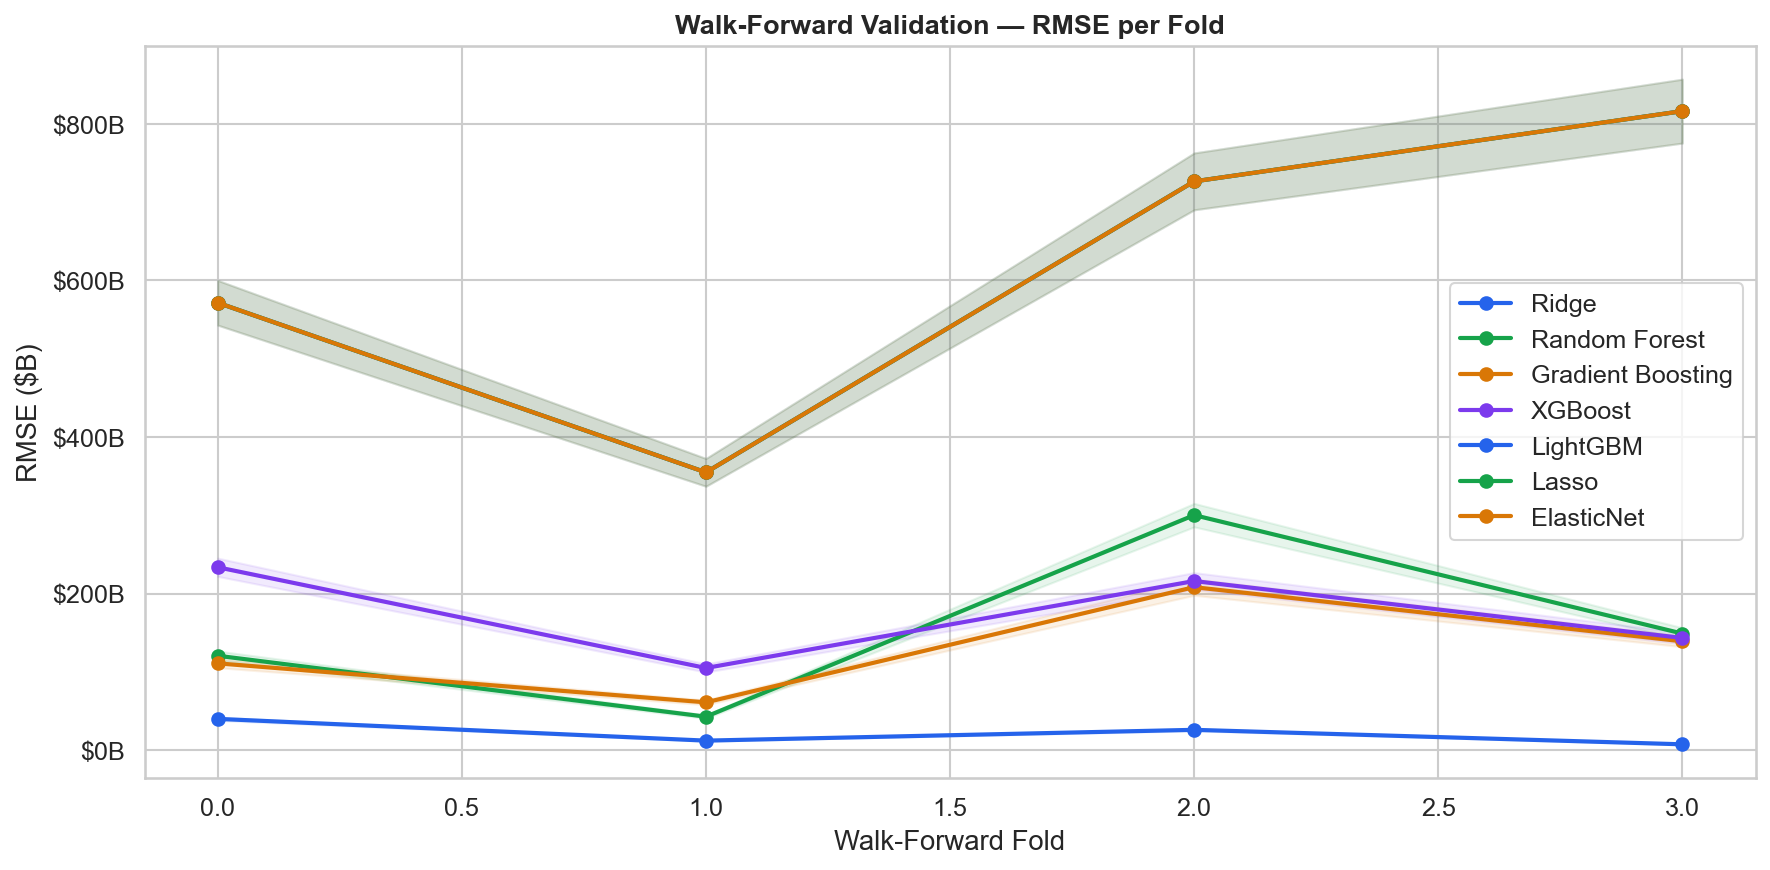

In [51]:
#Walk-forwards validation
wf_models = {
    "Ridge":              (Ridge(alpha=10),                          True),
    "Random Forest":      (RandomForestRegressor(100, random_state=42), False),
    "Gradient Boosting":  (GradientBoostingRegressor(n_estimators=100, random_state=42), False),
    "XGBoost":            (xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                             max_depth=4, random_state=42,
                                             verbosity=0), False),
    "LightGBM":           (lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                              max_depth=4, random_state=42,
                                              verbose=-1), False),
    "Lasso":              (Lasso(alpha=1e7, max_iter=10000),          True),
    "ElasticNet":         (ElasticNet(alpha=1e7, l1_ratio=0.5,
                                       max_iter=10000),               True)
}
ACCENT    = "#2563EB"
HIGHLIGHT = "#DC2626"
GREEN     = "#16A34A"
AMBER     = "#D97706"
PURPLE    = "#7C3AED"
NEUTRAL   = "#64748B"
wf_results = {name: [] for name in wf_models}
n_splits  = 4
split_size  = len(X_raw) // (n_splits + 1)
 
for fold in range(n_splits):
    idx_train_end = split_size * (fold + 1)
    idx_test_end  = idx_train_end + split_size
    if idx_test_end > len(X_raw):
        break
    X_tr, y_tr = X_raw[:idx_train_end], y[:idx_train_end]
    X_te, y_te = X_raw[idx_train_end:idx_test_end], y[idx_train_end:idx_test_end]
    X_tr_sc    = scaler.fit_transform(X_tr)
    X_te_sc    = scaler.transform(X_te)
    for name, (mdl, use_sc) in wf_models.items():
        X_f_tr = X_tr_sc if use_sc else X_tr
        X_f_te = X_te_sc if use_sc else X_te
        try:
            mdl.fit(X_f_tr, y_tr)
            preds = mdl.predict(X_f_te)
            wf_results[name].append(np.sqrt(mean_squared_error(y_te, preds)) / 1e3)
        except:
            wf_results[name].append(np.nan)
fig, ax = plt.subplots(figsize=(12, 6))
x_folds = np.arange(len(list(wf_results.values())[0]))
wf_colors = [ACCENT, GREEN, AMBER, PURPLE]
for i, (name, scores) in enumerate(wf_results.items()):
    valid = [(j, s) for j, s in enumerate(scores) if not np.isnan(s)]
    if valid:
        xs, ys = zip(*valid)
        ax.plot(xs, ys, marker="o", linewidth=2,
                color=wf_colors[i % len(wf_colors)], label=name)
        ax.fill_between(xs, [v * 0.95 for v in ys], [v * 1.05 for v in ys],
                        alpha=0.1, color=wf_colors[i % len(wf_colors)])
ax.set_xlabel("Walk-Forward Fold")
ax.set_ylabel("RMSE ($B)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}B"))
ax.set_title("Walk-Forward Validation — RMSE per Fold", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [52]:
# ── ML Leaderboard Plot ────────────────────────────────────────────────────
ml_board = sorted(all_ml_results.items(), key=lambda x: x[1]["RMSE"])
ml_names = [m[0] for m in ml_board]
ml_rmse  = [m[1]["RMSE"] / 1e3 for m in ml_board]
ml_r2    = [m[1]["R²"] for m in ml_board]
ml_mae   = [m[1]["MAE"] / 1e3 for m in ml_board]
 

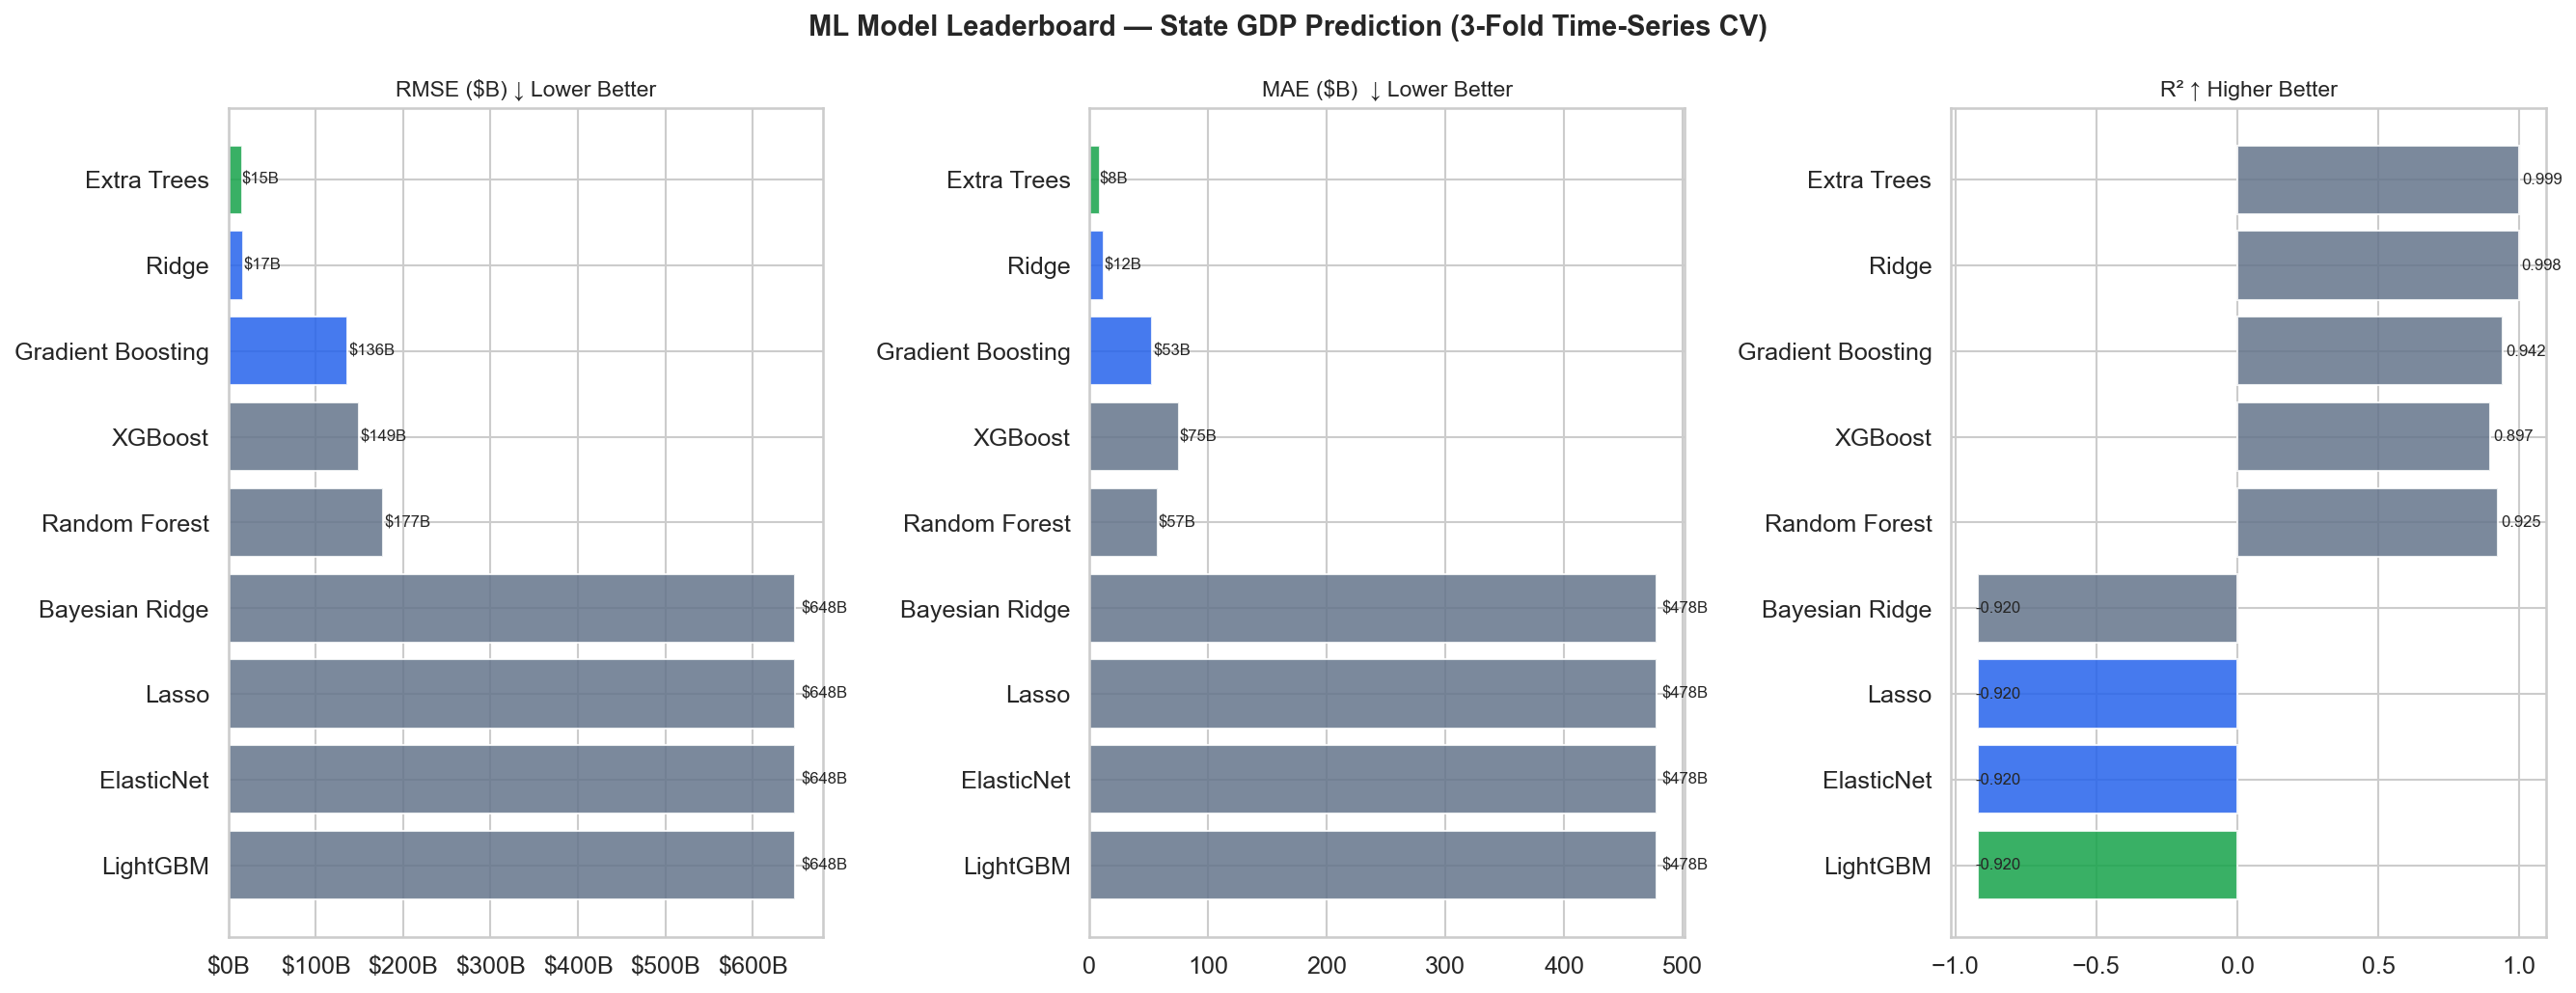

In [53]:
bar_colors = [GREEN if i == 0 else (ACCENT if i < 3 else NEUTRAL)
              for i in range(len(ml_board))]
 
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("ML Model Leaderboard — State GDP Prediction (3-Fold Time-Series CV)",
             fontsize=14, fontweight="bold")
 
for ax_i, (metric, vals, title, fmt) in enumerate([
    ("RMSE", ml_rmse, "RMSE ($B) ↓ Lower Better", "${x:,.0f}B"),
    ("MAE",  ml_mae,  "MAE ($B)  ↓ Lower Better",  "${x:,.0f}B"),
    ("R²",   ml_r2,   "R² ↑ Higher Better",        "{x:.3f}"),
]):
    colors_i = ([GREEN if i == 0 else (ACCENT if i < 3 else NEUTRAL)
                 for i in range(len(ml_board))]
                if metric != "R²" else
                [GREEN if i == len(ml_board)-1 else (ACCENT if i >= len(ml_board)-3 else NEUTRAL)
                 for i in range(len(ml_board))])
    bars = axes[ax_i].barh(ml_names[::-1], vals[::-1] if metric != "R²" else ml_r2[::-1],
                            color=colors_i[::-1], alpha=0.85)
    axes[ax_i].set_title(title, fontsize=11)
    for bar, val in zip(bars, (vals[::-1] if metric != "R²" else ml_r2[::-1])):
        axes[ax_i].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                        fmt.format(x=val) if "x" in fmt else f"{val:.3f}",
                        va="center", fontsize=8)
    if metric == "RMSE":
        axes[ax_i].xaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f"${x:,.0f}B"))
plt.tight_layout()
plt.show()

In [54]:
best_ml = ml_board[0]
print(f"\n{'ML Model':<24} {'RMSE ($B)':>10} {'MAE ($B)':>10} {'R²':>8}")
print("-" * 56)
for name, res in ml_board:
    print(f"{name:<24} {res['RMSE']/1e3:>10.1f} {res['MAE']/1e3:>10.1f} {res['R²']:>8.4f}")
print(f"\n→ BEST ML Model: {best_ml[0]} (RMSE ${best_ml[1]['RMSE']/1e3:.1f}B, R²={best_ml[1]['R²']:.4f})")


ML Model                  RMSE ($B)   MAE ($B)       R²
--------------------------------------------------------
Extra Trees                    15.3        8.3   0.9994
Ridge                          16.7       11.8   0.9982
Gradient Boosting             136.3       52.8   0.9419
XGBoost                       149.3       75.1   0.8973
Random Forest                 177.0       57.4   0.9246
Bayesian Ridge                648.3      477.7  -0.9199
Lasso                         648.3      477.7  -0.9199
ElasticNet                    648.3      477.7  -0.9199
LightGBM                      648.3      477.7  -0.9199

→ BEST ML Model: Extra Trees (RMSE $15.3B, R²=0.9994)


In [55]:
#Clustering
latest_year_qs = [q for q in Q_COLS if "2025" in q][:2]  # 2025Q1,Q2
state_ind = long[
    (long["GeoName"] != "United States *") &
    (~long["GeoName"].str.contains("overseas", case=False)) &
    (long["Quarter"].isin(latest_year_qs))
].pivot_table(index="GeoName", columns="Description", values="GDP_M", aggfunc="mean")
state_ind = state_ind.fillna(0)
 
# Also add total GDP and QoQ growth features
avg_growth = state_total.groupby("GeoName")["QoQ_Growth"].mean().rename("Avg_QoQ_Growth")
state_ind = state_ind.join(avg_growth, how="left").fillna(0)
 
X_clust = StandardScaler().fit_transform(state_ind)
state_labels = state_ind.index.tolist()

In [56]:
#Elbow Method
inertias    = []
sil_scores  = []
K_range     = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, km.labels_))
opt_k = K_range[np.argmax(sil_scores)]
print(f"\nOptimal K (max silhouette): {opt_k}")
print(f"Silhouette scores: {dict(zip(K_range, [f'{s:.3f}' for s in sil_scores]))}")


Optimal K (max silhouette): 2
Silhouette scores: {2: '0.731', 3: '0.456', 4: '0.378', 5: '0.383', 6: '0.239', 7: '0.235', 8: '0.263'}


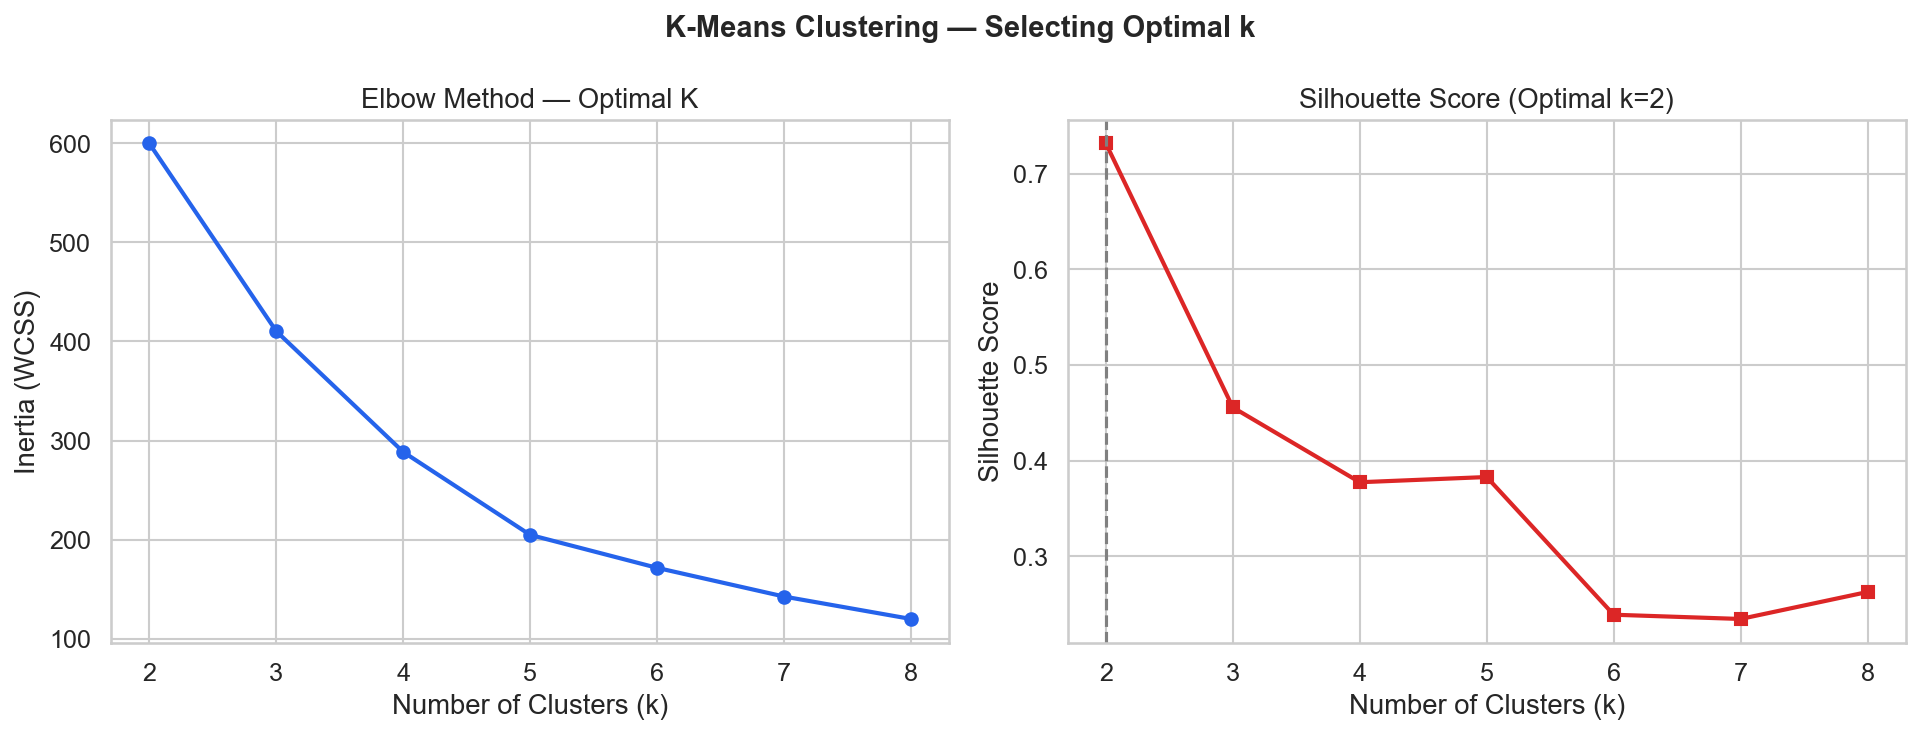

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(K_range, inertias, color=ACCENT, marker="o", linewidth=2)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method — Optimal K")
axes[0].set_xticks(list(K_range))
 
axes[1].plot(K_range, sil_scores, color=HIGHLIGHT, marker="s", linewidth=2)
axes[1].axvline(opt_k, color="gray", linestyle="--")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title(f"Silhouette Score (Optimal k={opt_k})")
axes[1].set_xticks(list(K_range))
plt.suptitle("K-Means Clustering — Selecting Optimal k", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

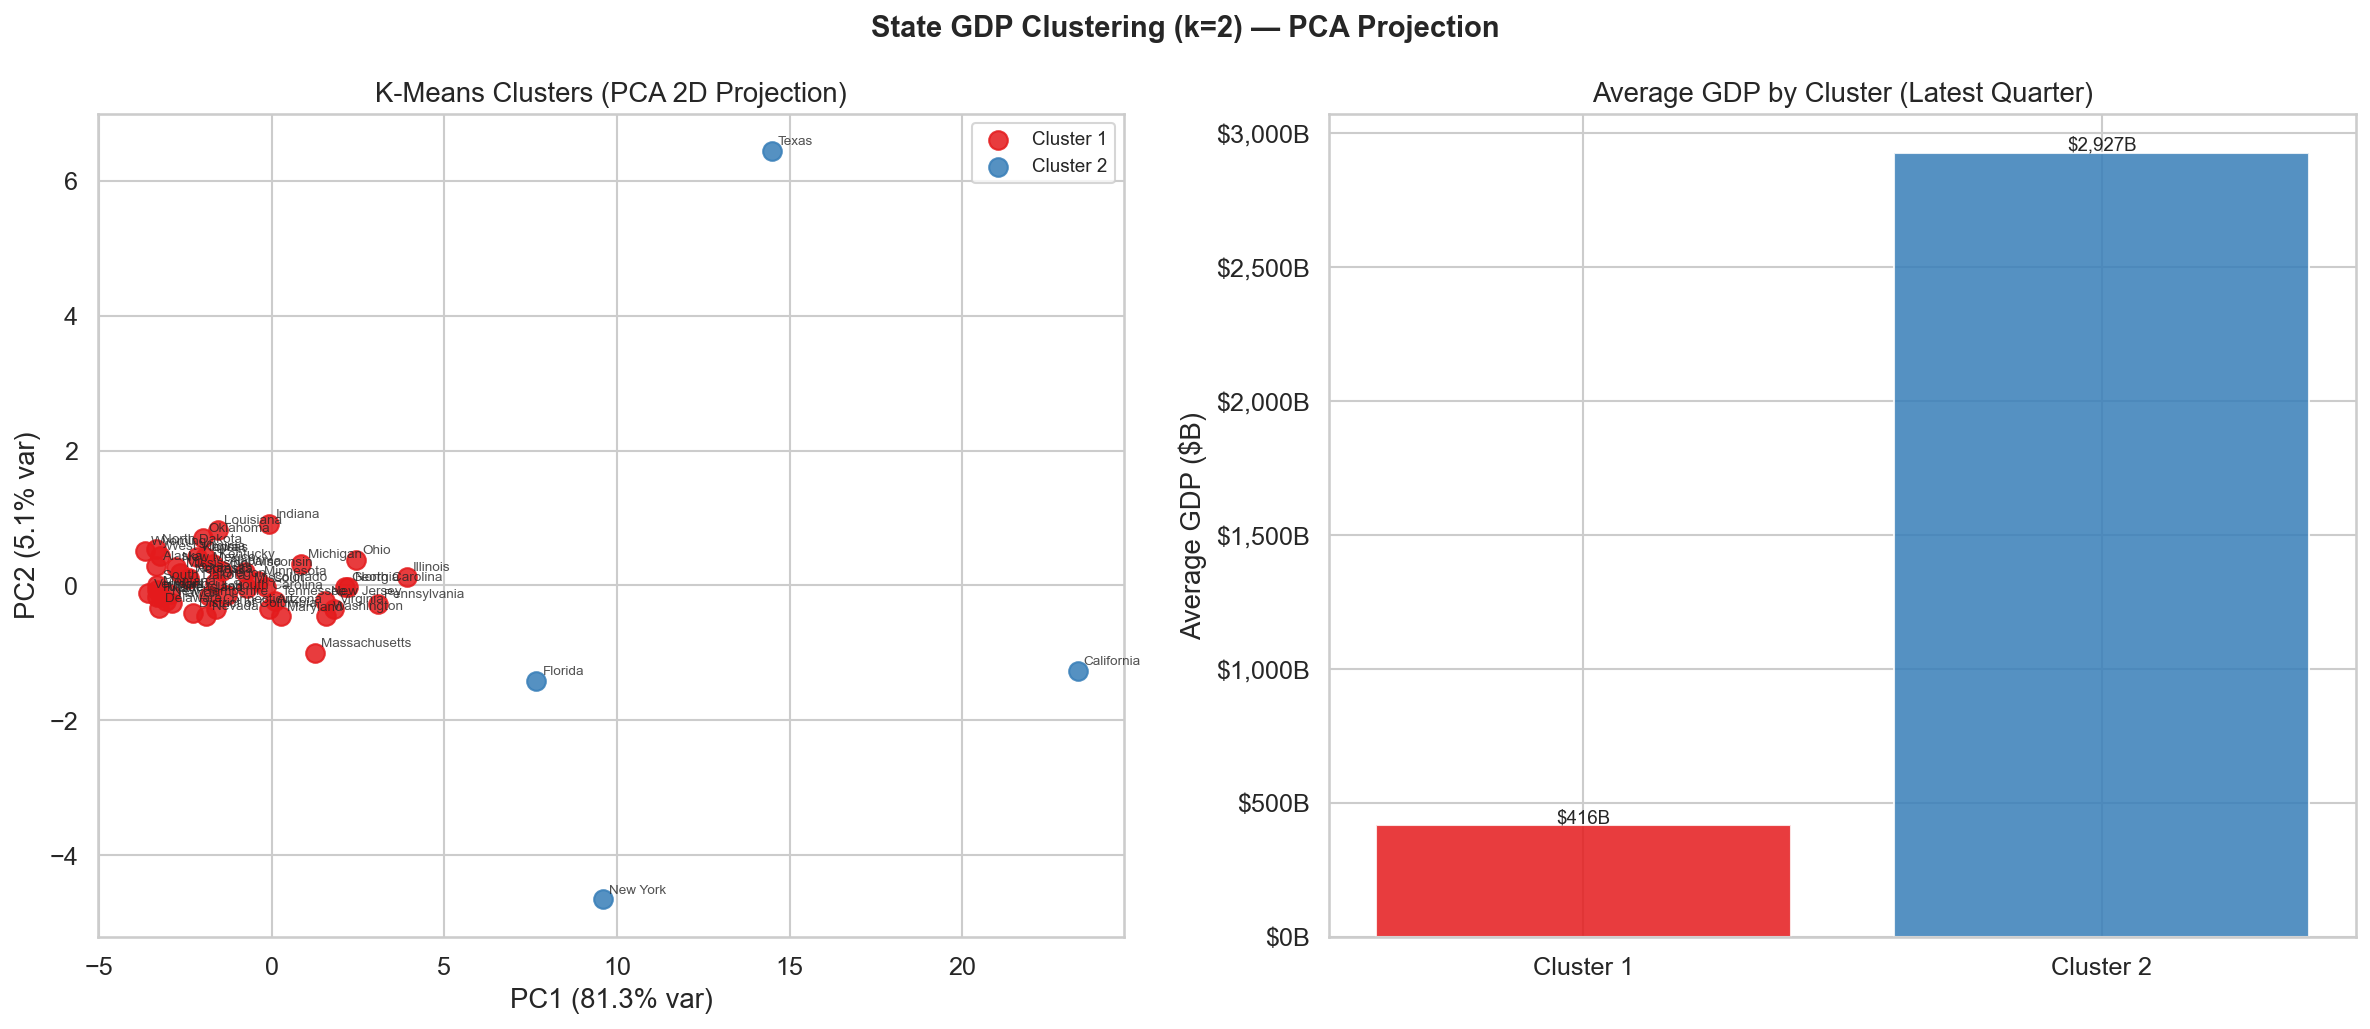

In [58]:
# ── Final K-Means Clustering ───────────────────────────────────────────────
km_final = KMeans(n_clusters=opt_k, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(X_clust)
state_ind["Cluster"] = cluster_labels
 
# PCA for 2-D visualization
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_clust)
var_ex = pca.explained_variance_ratio_
 
cluster_colors = plt.cm.Set1.colors[:opt_k]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"State GDP Clustering (k={opt_k}) — PCA Projection", fontsize=14, fontweight="bold")
 
ax = axes[0]
for k in range(opt_k):
    mask = cluster_labels == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=cluster_colors[k], s=80, label=f"Cluster {k+1}", alpha=0.85)
    for i, name in enumerate(state_labels):
        if cluster_labels[i] == k:
            ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]),
                        fontsize=6.5, alpha=0.8,
                        xytext=(3, 3), textcoords="offset points")
ax.set_xlabel(f"PC1 ({var_ex[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({var_ex[1]*100:.1f}% var)")
ax.set_title("K-Means Clusters (PCA 2D Projection)")
ax.legend(fontsize=9)
 
# Cluster means
cluster_gdp = state_total.copy()
cluster_gdp = cluster_gdp[cluster_gdp["Quarter"] == latest_q]
cluster_gdp["Cluster"] = cluster_gdp["GeoName"].map(
    dict(zip(state_labels, cluster_labels))).fillna(-1).astype(int)
cluster_means = cluster_gdp[cluster_gdp["Cluster"] >= 0].groupby("Cluster")["GDP_B"].mean()
 
ax2 = axes[1]
ax2.bar(range(opt_k), cluster_means.values, color=cluster_colors[:opt_k], alpha=0.85)
ax2.set_xticks(range(opt_k))
ax2.set_xticklabels([f"Cluster {i+1}" for i in range(opt_k)])
ax2.set_ylabel("Average GDP ($B)")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}B"))
ax2.set_title("Average GDP by Cluster (Latest Quarter)")
for i, val in enumerate(cluster_means.values):
    ax2.text(i, val + 10, f"${val:,.0f}B", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


In [59]:
# Print cluster membership
for k in range(opt_k):
    members = [s for s, c in zip(state_labels, cluster_labels) if c == k]
    print(f"\nCluster {k+1}: {', '.join(sorted(members))}")


Cluster 1: Alabama, Alaska, Arizona, Arkansas, Colorado, Connecticut, Delaware, District of Columbia, Georgia, Hawaii, Idaho, Illinois, Indiana, Iowa, Kansas, Kentucky, Louisiana, Maine, Maryland, Massachusetts, Michigan, Minnesota, Mississippi, Missouri, Montana, Nebraska, Nevada, New Hampshire, New Jersey, New Mexico, North Carolina, North Dakota, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, South Carolina, South Dakota, Tennessee, Utah, Vermont, Virginia, Washington, West Virginia, Wisconsin, Wyoming

Cluster 2: California, Florida, New York, Texas


Summary

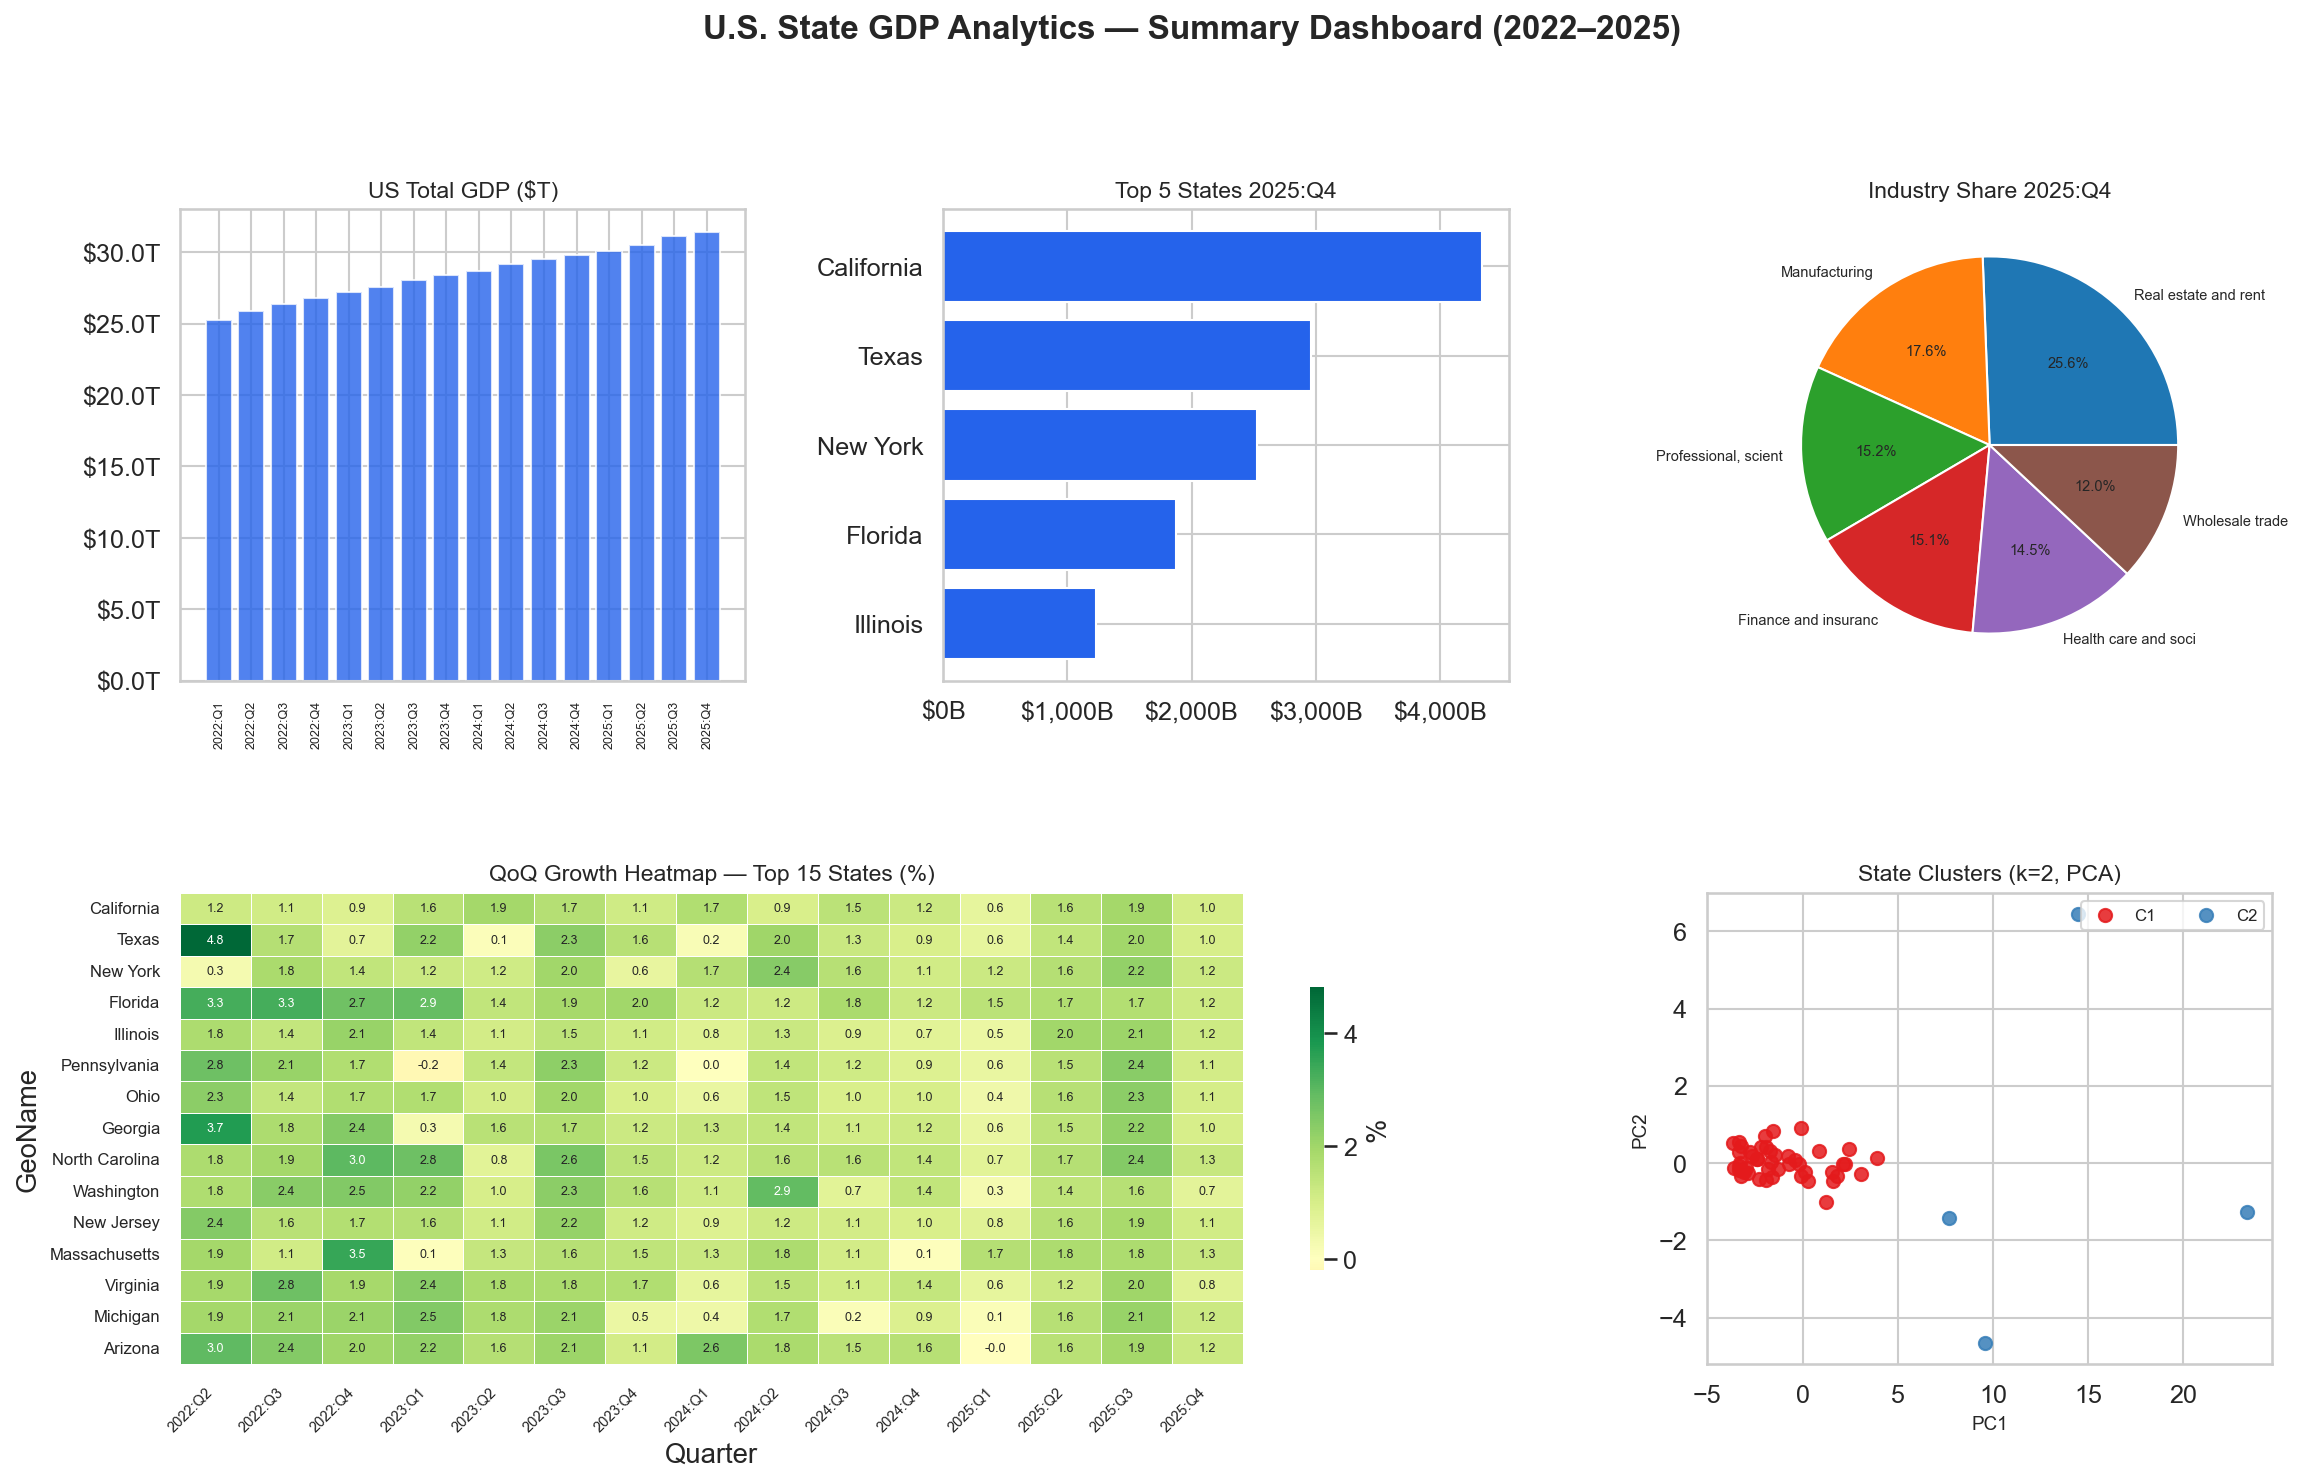

In [63]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle("U.S. State GDP Analytics — Summary Dashboard (2022–2025)",
             fontsize=16, fontweight="bold", y=1.01)
 
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)
 
# Panel 1: US GDP bar
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(range(len(Q_COLS)), us_total["GDP_T"], color=ACCENT, alpha=0.8)
ax1.set_title("US Total GDP ($T)", fontsize=11)
ax1.set_xticks(range(len(Q_COLS)))
ax1.set_xticklabels(Q_COLS, rotation=90, fontsize=6)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:.1f}T"))
 
# Panel 2: Top 5 states latest quarter
ax2 = fig.add_subplot(gs[0, 1])
top5_df = state_latest.head(5)
ax2.barh(top5_df["GeoName"][::-1], top5_df["GDP_B"][::-1], color=ACCENT)
ax2.set_title(f"Top 5 States {latest_q}", fontsize=11)
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}B"))
 
# Panel 3: Industry share (pie)
ax3 = fig.add_subplot(gs[0, 2])
us_ind_pie = us_ind_latest.head(6)
ax3.pie(us_ind_pie["GDP_B"], labels=[d.strip()[:20] for d in us_ind_pie["Description"]],
        autopct="%1.1f%%", colors=plt.cm.tab10.colors[:6],
        textprops={"fontsize": 7})
ax3.set_title(f"Industry Share {latest_q}", fontsize=11)
 
# Panel 4: Growth heatmap (mini)
ax4 = fig.add_subplot(gs[1, :2])
mini_states = state_latest.head(15)["GeoName"].tolist()
mini_pivot  = state_qoq_pivot.loc[mini_states]
sns.heatmap(mini_pivot, ax=ax4, cmap="RdYlGn", center=0,
            annot=True, fmt=".1f", annot_kws={"size": 6},
            linewidths=0.3, cbar_kws={"shrink": 0.6, "label": "%"})
ax4.set_title("QoQ Growth Heatmap — Top 15 States (%)", fontsize=11)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha="right", fontsize=7)
ax4.set_yticklabels(ax4.get_yticklabels(), fontsize=8)
 
# Panel 5: Cluster PCA mini
ax5 = fig.add_subplot(gs[1, 2])
for k in range(opt_k):
    mask = cluster_labels == k
    ax5.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=cluster_colors[k], s=40, label=f"C{k+1}", alpha=0.85)
ax5.set_title(f"State Clusters (k={opt_k}, PCA)", fontsize=11)
ax5.set_xlabel("PC1", fontsize=9)
ax5.set_ylabel("PC2", fontsize=9)
ax5.legend(fontsize=8, ncol=2)
plt.show()